# IntPhys2 — Prediction-based Evaluation

## Surprisal formulation

Given a video $V$ of $N$ frames and a model handling $M < N$ frames, we form overlapping sliding windows of $M$ frames with stride $S$, giving windows starting at frames $0, S, 2S, \ldots, N{-}M$. Each window is split into a **context** of $C$ frames and a **target** of $T = M - C$ frames. The per-window surprise is:

$$\text{Surprise}_w = d\!\left(p\!\left(f(V_{w:w+C})\right),\; f'(V_{w+C:w+M})\right) \tag{1}$$

where $w$ is the window's starting frame, $d$ a distance measure, $f$ the encoder for the context, $f'$ the target encoder, and $p$ the predictor.

### V-JEPA 2

$$\text{Surprise}_w = d\!\left(p\!\left(f(V_{w:w+C})\right),\; \mathrm{LN}\!\left([f'(V_{w:w+M})]_T\right)\right)$$

- $f$ — V-JEPA 2 encoder (frozen ViT-H), applied to context patch tokens
- $f'$ — target encoder (EMA copy of $f$), applied to the **full** window; $[\cdot]_T$ selects the target patch positions $w{+}C \to w{+}M$
- $p$ — predictor (separate ViT), takes context encodings and mask tokens and predicts target-region representations
- $\mathrm{LN}$ — layer normalization over the feature dimension, applied to targets before computing $d$
- $d$ — mean L1 distance over all $N_T$ target tokens and feature dimension $D$:

$$d(\hat{z}, z) = \frac{1}{N_T \cdot D}\sum_{n=1}^{N_T}\sum_{d=1}^{D} |\hat{z}_{n,d} - z_{n,d}|$$

Surprise is measured in **representation space** (not pixel space). The EMA target encoder provides stable targets decoupled from the online encoder weights.

### VideoMAEv2

For VideoMAEv2, $f$ is the encoder, $f'$ is the **identity** (patch-normalized pixel values), and $p$ is the decoder — so surprise is measured directly in pixel space.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

# figures and computations


In [2]:
# ---------------------------------------------------------------------------
# Configuration — edit these before running
# ---------------------------------------------------------------------------

MODEL_NAME  = "vjepa2"          
# label used in plot titles and filenames
PTH_FOLDER  = "/data/kxzheng/models/checkpoint/vjepa-2-h/intphys_v2/intphys2-main-default"                
# path to folder containing losses_*.pth files
METADATA_CSV = "/data/kxzheng/data/IntPhys2/Main/metadata.csv"               
# path to metadata.csv for this split
DATASET     = "intphys2-main" # intphys2-debug | intphys2-main | intphys2-heldout

# Where to save figures (set to None to skip saving)
SAVE_DIR    = "./figures"

In [98]:
# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def load_pth_files(pth_folder, dataset):
    if dataset == "intphys2-main":
        files = sorted(glob.glob(os.path.join(pth_folder, "losses_*rank*.pth")))
    else:
        files = sorted(glob.glob(os.path.join(pth_folder, "losses_*.pth")))
        files = [f for f in files if "rank" not in os.path.basename(f)]
    if not files:
        raise FileNotFoundError(f"No .pth files found in {pth_folder}")
    all_losses, all_names, meta = [], [], None
    for f in files:
        data = torch.load(f, map_location="cpu", weights_only=False)
        if meta is None:
            meta = {k: v for k, v in data.items() if k not in ("losses", "names")}
        all_losses.append(data["losses"])
        all_names.extend(list(data["names"]))
    max_t = max(l.shape[2] for l in all_losses)
    padded = [torch.nn.functional.pad(l, (0, max_t - l.shape[2])) for l in all_losses]
    return torch.cat(padded, dim=0), all_names, meta   # [N, C, T]


def load_metadata(metadata_csv):
    df_gt_labels = pd.read_csv(metadata_csv)
    df_gt_labels["_basename"] = df_gt_labels["file_name"].apply(lambda x: os.path.basename(str(x)))
    df_gt_labels = df_gt_labels.rename(columns={'name': 'filename'})
    #predicted_labels.filename = predicted_labels.filename.astype(str)
    df_gt_labels.filename = df_gt_labels.filename.astype(str)
    return df_gt_labels

def label_target(row):
    if "Impossible" in row["type"]:
        return 0
    elif "Possible" in row["type"]:
        return 1
    else:
        print("Parsing Error!")

def aggregate_surprise(losses):
    """Mean L1 loss per video per context length, ignoring zero-padded frames.

    losses : Tensor [N_videos, N_ctx, T]
    returns: ndarray [N_videos, N_ctx]
    """
    mask = (losses > 0).float()
    scores = (losses * mask).sum(dim=2) / mask.sum(dim=2).clamp(min=1)
    return scores.numpy()   # [N_videos, N_ctx]

# def build_results_df(losses, names, metadata_df):
#     scores = aggregate_surprise(losses)         # [N_videos, N_ctx]
#     name_to_idx = {n: i for i, n in enumerate(names)}
#     df = metadata_df.copy()
#     df["video_idx"] = df["_basename"].map(name_to_idx)
#     df = df.dropna(subset=["video_idx"])
#     df["video_idx"] = df["video_idx"].astype(int)
#     # per-context scores as a list, max across contexts as the summary score
#     df["surprise_scores"] = df["video_idx"].apply(lambda i: scores[i])       # [N_ctx]
#     df["surprise_score"]  = df["surprise_scores"].apply(lambda s: s.max())   # scalar
#     df["target"] = df.apply(label_target, axis=1).astype(int)
#     return df

# def compute_scene_accuracy(results_df, ctx_lengths):
#     """Compute scene accuracy per context length, report max across context lengths.

#     For each scene: correct_c = impossible mean surprise > possible mean surprise
#     at context length c. Overall correct = max across context lengths.
#     """
#     rows = []
#     for scene_idx, grp in results_df.groupby("SceneIndex"):
#         possible   = grp[grp["target"] == 1]["surprise_scores"].tolist()
#         impossible = grp[grp["target"] == 0]["surprise_scores"].tolist()
#         if not possible or not impossible:
#             continue
#         pos_arr = np.stack(possible)    # [n_pos, N_ctx]
#         imp_arr = np.stack(impossible)  # [n_imp, N_ctx]
#         correct_per_ctx = (imp_arr.mean(0) > pos_arr.mean(0)).astype(int)  # [N_ctx]
#         row = {
#             "SceneIndex": scene_idx,
#             "correct":    int(correct_per_ctx.max()),   # max across ctx lengths
#             "condition":  grp["condition"].iloc[0],
#             "env":        grp["env"].iloc[0],
#             "Difficulty": grp["Difficulty"].iloc[0],
#             "game_name":  grp["game_name"].iloc[0],
#             "Camera":     grp["Camera"].iloc[0],
#         }
#         for c, ctx in enumerate(ctx_lengths):
#             row[f"correct_ctx{ctx}"] = int(correct_per_ctx[c])
#         rows.append(row)
#     return pd.DataFrame(rows)

def build_results_df(losses, names, metadata_df, ctx_lengths):
    scores = aggregate_surprise(losses)         # [N_videos, N_ctx]
    name_to_idx = {n: i for i, n in enumerate(names)}
    df = metadata_df.copy()
    df["video_idx"] = df["_basename"].map(name_to_idx)
    df = df.dropna(subset=["video_idx"])
    df["video_idx"] = df["video_idx"].astype(int)
    for c, ctx in enumerate(ctx_lengths):
        df[f"surprise_ctx{ctx}"] = df["video_idx"].apply(lambda i: scores[i, c])
    df["surprise_score"] = df["video_idx"].apply(lambda i: scores[i].max())
    df["target"] = df.apply(label_target, axis=1).astype(int)
    return df

def compute_scene_accuracy(results_df, ctx_lengths):
    rows = []
    for scene_idx, grp in results_df.groupby("SceneIndex"):
        possible   = grp[grp["target"] == 1]
        impossible = grp[grp["target"] == 0]
        if possible.empty or impossible.empty:
            continue
        row = {
            "SceneIndex": scene_idx,
            "condition":  grp["condition"].iloc[0],
            "env":        grp["env"].iloc[0],
            "Difficulty": grp["Difficulty"].iloc[0],
            "game_name":  grp["game_name"].iloc[0],
            "Camera":     grp["Camera"].iloc[0],
        }
        correct_per_ctx = []
        for ctx in ctx_lengths:
            col = f"surprise_ctx{ctx}"
            correct = int(impossible[col].mean() > possible[col].mean())
            row[f"correct_ctx{ctx}"] = correct
            correct_per_ctx.append(correct)
        rows.append(row)
    return pd.DataFrame(rows)

def savefig(fig, name, SAVE_DIR=None):
    if SAVE_DIR is None:
        return
    os.makedirs(SAVE_DIR, exist_ok=True)
    path = os.path.join(SAVE_DIR, f"{MODEL_NAME}_{name}.png")
    fig.savefig(path, bbox_inches="tight")
    print(f"Saved: {path}")

In [113]:
# ---------------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------------

losses, names, meta = load_pth_files(PTH_FOLDER, DATASET)
metadata_df         = load_metadata(METADATA_CSV) # easy, medium, hard, + unknown split without metadata
ctx_lengths         = meta.get("context_lengths", list(range(losses.shape[1])))
results_df          = build_results_df(losses, names, metadata_df, ctx_lengths)
scene_acc           = compute_scene_accuracy(results_df,ctx_lengths)

In [145]:
ctx_cols = [f"correct_ctx{c}" for c in ctx_lengths]

# Find best context length per condition
acc_by_condition_ctx = (
    scene_acc[["condition"] + ctx_cols]
    .groupby("condition")
    .mean()
)
best_ctx_per_condition = acc_by_condition_ctx.idxmax(axis=1).str.replace("correct_ctx", "").astype(int)

# For each scene, use the correct value from its condition's best context
scene_acc["correct_best_ctx"] = scene_acc.apply(
    lambda row: row[f"correct_ctx{best_ctx_per_condition[row['condition']]}"], axis=1
)
scene_acc["best_ctx"] = scene_acc["condition"].map(best_ctx_per_condition)

# Replace correct so all downstream cells (plots, bootstrap, etc.) use this
#scene_acc["correct"] = scene_acc["correct_best_ctx"]

print("Best context per condition:")
print(best_ctx_per_condition.to_string())
print(f"\nOverall accuracy (best ctx per condition): {scene_acc['correct_best_ctx'].mean()*100:.1f}%")

######

# overall = scene_acc["correct_best_ctx"].mean() * 100
overall = scene_acc[scene_acc["Difficulty"]!='Unknown']["correct_best_ctx"].mean() * 100
print(f"overall_known: {overall:.1f}%")

print(f"Model     : {MODEL_NAME}")
print(f"Dataset   : {DATASET}")
print(f"Videos    : {losses.shape[0]} in .pth | {len(results_df)} matched in metadata")
print(f"Scenes    : {len(scene_acc)}")
print(f"Overall   : {overall:.1f}%")
print(f"Ctx lens  : {ctx_lengths}")
print(f"Loss shape: {list(losses.shape)}  [N_videos, N_ctx, N_time_steps]")

Best context per condition:
condition
continuity      36
immutability    42
permanence      12
solidity        42

Overall accuracy (best ctx per condition): 54.2%
overall_known: 53.8%
Model     : vjepa2
Dataset   : intphys2-main
Videos    : 1012 in .pth | 1012 matched in metadata
Scenes    : 253
Overall   : 53.8%
Ctx lens  : [12, 18, 24, 30, 36, 42]
Loss shape: [1012, 6, 44]  [N_videos, N_ctx, N_time_steps]


In [147]:
ctx_cols = [f"correct_ctx{c}" for c in ctx_lengths]

# Find best context length per condition
acc_by_scenario_ctx = (
    scene_acc[["SceneIndex"] + ctx_cols]
    .groupby("SceneIndex")
    .mean()
)
best_ctx_per_scenario= acc_by_scenario_ctx.idxmax(axis=1).str.replace("correct_ctx", "").astype(int)

# For each scene, use the correct value from its scenario's best context
scene_acc["correct_best_ctx"] = scene_acc.apply(
    lambda row: row[f"correct_ctx{best_ctx_per_scenario[row['SceneIndex']]}"], axis=1
)

print("Best context per scenario:")
print(best_ctx_per_scenario.to_string())
print(f"\nOverall accuracy (best ctx per scenario): {scene_acc['correct_best_ctx'].mean()*100:.1f}%")

Best context per scenario:
SceneIndex
0        12
1        12
10       12
100      12
101      12
102      18
103      12
104      24
105      12
106      24
107      12
108      12
109      12
11       12
110      12
111      12
112      12
113      12
114      12
115      12
116      36
117      12
118      12
119      12
12       12
120      12
121      12
122      12
123      12
124      12
125      12
126      12
127      12
128      12
129      12
13       12
130      12
131      12
132      12
133      12
134      18
135      12
136      12
137      12
138      12
139      12
14       12
140      12
141      12
142      12
143      12
144      12
145      12
146      12
147      12
148      12
149      18
15       12
150      12
151      12
152      12
153      12
154      12
154_0    12
155      12
155_0    12
156      12
156_0    12
157      12
158      12
159      12
16       12
160      12
161      12
162      12
163      12
164      12
165      12
166      12
167      12
16

In [161]:
overall_unknown = scene_acc["correct_best_ctx"].mean() * 100
print(f"overall_unknown: {overall_unknown:.1f}%")
overall = scene_acc[scene_acc["Difficulty"]!='Unknown']["correct_best_ctx"].mean() * 100
print(f"overall_known: {overall:.1f}%")

print(f"Model     : {MODEL_NAME}")
print(f"Dataset   : {DATASET}")
print(f"Videos    : {losses.shape[0]} in .pth | {len(results_df)} matched in metadata")
print(f"Scenes    : {len(scene_acc)}")
print(f"Overall   : {overall:.1f}%")
print(f"Ctx lens  : {ctx_lengths}")
print(f"Loss shape: {list(losses.shape)}  [N_videos, N_ctx, N_time_steps]")

overall_unknown: 60.9%
overall_known: 60.5%
Model     : vjepa2
Dataset   : intphys2-main
Videos    : 1012 in .pth | 1012 matched in metadata
Scenes    : 253
Overall   : 60.5%
Ctx lens  : [12, 18, 24, 30, 36, 42]
Loss shape: [1012, 6, 44]  [N_videos, N_ctx, N_time_steps]


In [159]:
# Accuracy values showing best model performance for each difficulty level.
accs = scene_acc.groupby("Difficulty")["correct_best_ctx"].mean() * 100
for difficulty, acc in accs.items():
    print(f"{difficulty}: {acc:.1f}%")


Easy: 61.5%
Hard: 52.4%
Medium: 67.0%
Unknown: 62.8%


In [164]:
# # Accuracy across property and camera 
# accs = scene_acc.groupby(["condition", "Camera"])["correct_best_ctx"].mean() * 100
# accs

accs = scene_acc.groupby(["condition", "Camera"])["correct_best_ctx"].mean() * 100
pivot = accs.unstack("Camera")
pivot.loc["Overall"] = scene_acc.groupby("Camera")["correct_best_ctx"].mean() * 100
print(pivot.to_string(float_format=lambda x: f"{x:.1f}%"))

Camera        Fixed  Moving
condition                  
continuity    46.2%   76.5%
immutability  53.8%   64.7%
permanence    50.0%   47.1%
solidity      76.9%   66.0%
Overall       56.7%   63.8%


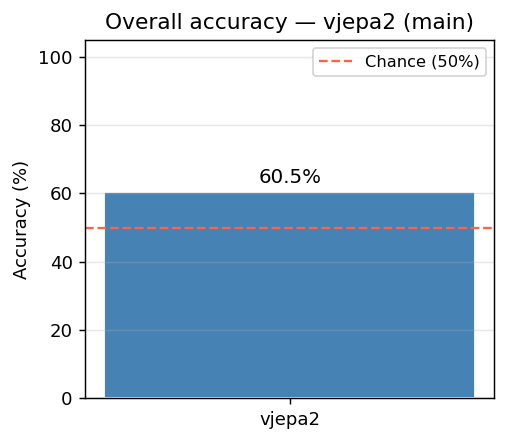

In [162]:
# ---------------------------------------------------------------------------
# Accuracy — overall
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(4, 3.5))
bar = ax.bar([MODEL_NAME], [overall], color="steelblue", edgecolor="white")
ax.axhline(50, color="tomato", linestyle="--", linewidth=1.3, label="Chance (50%)")
ax.set_ylim(0, 105)
ax.set_ylabel("Accuracy (%)")
ax.set_title(f"Overall accuracy — {MODEL_NAME} ({DATASET.split('-')[-1]})")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.text(bar[0].get_x() + bar[0].get_width()/2, overall + 1.5,
        f"{overall:.1f}%", ha="center", va="bottom", fontsize=11)
plt.tight_layout()
savefig(fig, "accuracy_overall")
plt.show()

In [120]:
def bootstrap_accuracy(scene_acc, group_col, n_bootstrap=1000, ci=95):
    """Bootstrap confidence intervals for accuracy grouped by a metadata column.

    Samples scenes with replacement n_bootstrap times and recomputes accuracy
    per group value each time.

    Parameters
    ----------
    scene_acc    : DataFrame with columns [SceneIndex, correct, <group_col>, ...]
    group_col    : str — column to group by (e.g. "condition", "Difficulty", "Cam")
    n_bootstrap  : int — number of bootstrap resamples
    ci           : float — confidence interval width (e.g. 95 for 95% CI)

    Returns
    -------
    DataFrame with columns: <group_col>, mean_acc, ci_lo, ci_hi, n_scenes
    """
    lo = (100 - ci) / 2
    hi = 100 - lo
    group_vals = scene_acc[group_col].unique()
    records = []

    for val in group_vals:
        subset = scene_acc[scene_acc[group_col] == val]["correct_best_ctx"].values
        if len(subset) == 0:
            continue
        boot_means = [
            np.random.choice(subset, size=len(subset), replace=True).mean()
            for _ in range(n_bootstrap)
        ]
        records.append({
            group_col:  val,
            "mean_acc": subset.mean() * 100,
            "ci_lo":    np.percentile(boot_means, lo) * 100,
            "ci_hi":    np.percentile(boot_means, hi) * 100,
            "n_scenes": len(subset),
        })

    return pd.DataFrame(records).sort_values("mean_acc", ascending=False).reset_index(drop=True)


def plot_bootstrap_accuracy(scene_acc, group_col, n_bootstrap=1000, ci=95):
    """Bar chart with bootstrapped CI error bars."""
    df  = bootstrap_accuracy(scene_acc, group_col, n_bootstrap, ci)
    xs  = range(len(df))
    err_lo = df["mean_acc"] - df["ci_lo"]
    err_hi = df["ci_hi"]    - df["mean_acc"]

    fig, ax = plt.subplots(figsize=(max(5, len(df) * 1.2), 4))
    ax.bar(xs, df["mean_acc"], color="steelblue", edgecolor="white",
           yerr=[err_lo, err_hi], capsize=0, error_kw={"linewidth": 1.5, "color": "black"})
    ax.axhline(50, color="tomato", linestyle="--", linewidth=1.3, label="Chance (50%)")
    ax.set_xticks(list(xs))
    ax.set_xticklabels(
        [f"{row[group_col]}\nn={row['n_scenes']}" for _, row in df.iterrows()],
        rotation=30, ha="right", fontsize=9,
    )
    ax.set_ylim(0, 115)
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(f"{MODEL_NAME} — accuracy by {group_col}  ({ci}% CI, {n_bootstrap} bootstrap samples)")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    savefig(fig, f"accuracy_{group_col}_bootstrap")
    plt.show()
    return df

In [121]:
bootstrap_accuracy(scene_acc, 'condition', n_bootstrap=1000, ci=95)

,condition,mean_acc,ci_lo,ci_hi,n_scenes
0,solidity,61.643836,49.315068,72.602740,73
1,continuity,56.666667,43.333333,68.333333,60
2,immutability,55.000000,41.666667,66.666667,60
3,permanence,41.666667,30.000000,55.000000,60


In [122]:
bootstrap_accuracy(scene_acc, 'Difficulty', n_bootstrap=1000, ci=95)

,Difficulty,mean_acc,ci_lo,ci_hi,n_scenes
0,Medium,61.000000,51.000000,70.000000,100
1,Unknown,55.813953,41.860465,69.767442,43
2,Easy,53.846154,34.615385,73.076923,26
3,Hard,45.238095,34.523810,55.982143,84


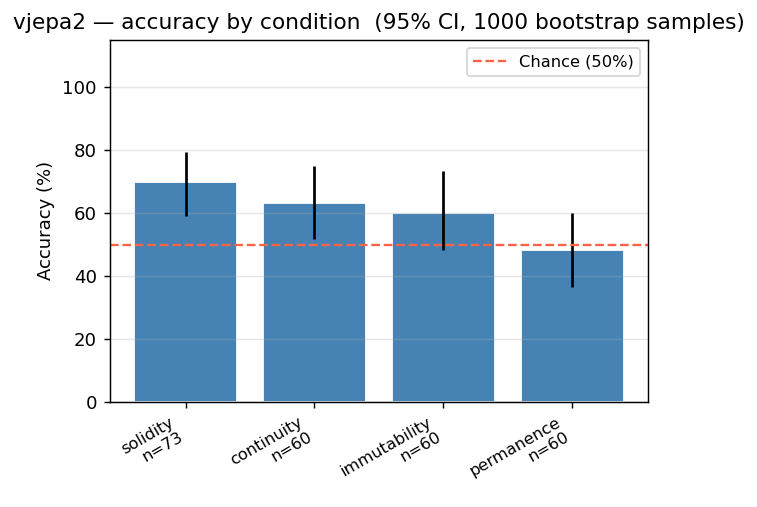

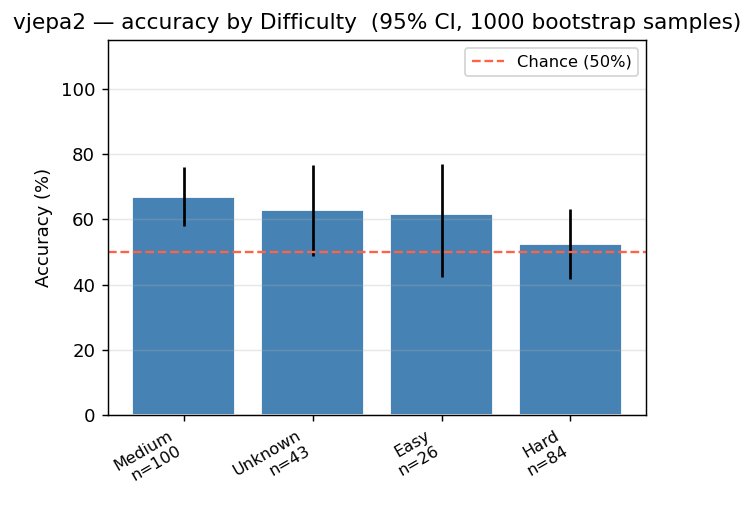

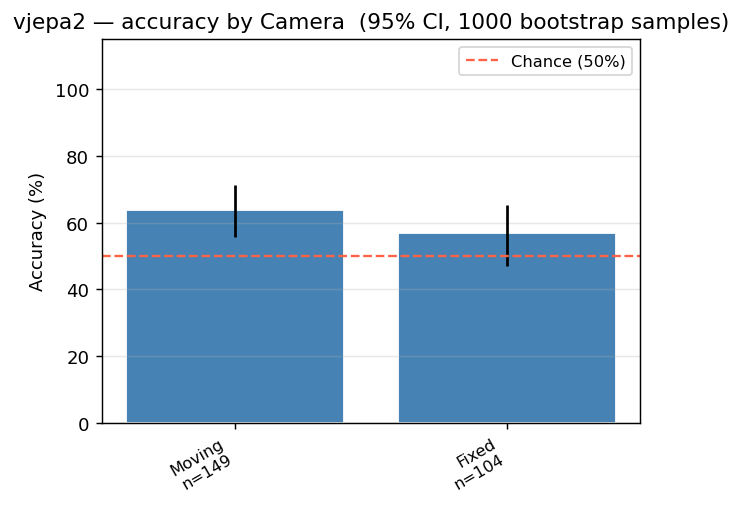

In [163]:
GROUP_COLS = ["condition", "Difficulty", "Camera"] # "env", "game_name",

for group in GROUP_COLS:
    plot_bootstrap_accuracy(scene_acc, group, n_bootstrap=1000, ci=95)

In [126]:
results_df

,SceneIndex,filename,file_name,game_name,condition,env,type,occluder,Difficulty,Camera,_basename,video_idx,surprise_ctx12,surprise_ctx18,surprise_ctx24,surprise_ctx30,surprise_ctx36,surprise_ctx42,surprise_score,target
0,0,083861b17a8b3f4bef7e3aaad0b960318a5ea19ca98258...,Videos/083861b17a8b3f4bef7e3aaad0b960318a5ea19...,FixedJumpSolidity,solidity,BasicLevel_0,1_Possible,NaN,Easy,Fixed,083861b17a8b3f4bef7e3aaad0b960318a5ea19ca98258...,261,0.689060,0.684143,0.682045,0.680690,0.678614,0.676760,0.689060,1
1,0,56c044c79b791ff1d2eae592c3af1914772d79a23c9603...,Videos/56c044c79b791ff1d2eae592c3af1914772d79a...,FixedJumpSolidity,solidity,BasicLevel_0,1_Impossible,NaN,Easy,Fixed,56c044c79b791ff1d2eae592c3af1914772d79a23c9603...,599,0.691215,0.686396,0.684002,0.682266,0.680052,0.677928,0.691215,0
2,0,4b2779c2649b64094af506b8783525387c2f7cd52dd8f5...,Videos/4b2779c2649b64094af506b8783525387c2f7cd...,FixedJumpSolidity,solidity,BasicLevel_0,2_Impossible,NaN,Easy,Fixed,4b2779c2649b64094af506b8783525387c2f7cd52dd8f5...,588,0.690434,0.685921,0.683760,0.682268,0.680181,0.678134,0.690434,0
3,0,66a6de26327fe7661ac4fec04da96d0710d2177afad8ba...,Videos/66a6de26327fe7661ac4fec04da96d0710d2177...,FixedJumpSolidity,solidity,BasicLevel_0,2_Possible,NaN,Easy,Fixed,66a6de26327fe7661ac4fec04da96d0710d2177afad8ba...,614,0.689399,0.685127,0.682881,0.681396,0.679387,0.677561,0.689399,1
4,1,0996318787089d31d84af8327bb044e77120cd0a6c6eb7...,Videos/0996318787089d31d84af8327bb044e77120cd0...,SolidityFallingFlat,solidity,BasicLevel_0,1_Possible,CubeRed,Easy,Fixed,0996318787089d31d84af8327bb044e77120cd0a6c6eb7...,11,0.693956,0.690910,0.689207,0.688146,0.686905,0.685781,0.693956,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,236,d833404a2f844380be4f470e9b88d844cf3d2a7ec275cf...,Videos/d833404a2f844380be4f470e9b88d844cf3d2a7...,SphereFallingDown,continuity,RuralAustralia03_0,2_Possible,NaN,Hard,Fixed,d833404a2f844380be4f470e9b88d844cf3d2a7ec275cf...,471,0.677841,0.673588,0.671366,0.670101,0.668505,0.667651,0.677841,1
1008,237,04b12306cdd2dc5791e66f3fcc7fd49235fcaea0abfffd...,Videos/04b12306cdd2dc5791e66f3fcc7fd49235fcaea...,SphereFallingDown,continuity,ParkingGarage_0,1_Possible,NaN,Hard,Fixed,04b12306cdd2dc5791e66f3fcc7fd49235fcaea0abfffd...,762,0.671914,0.668383,0.666771,0.665323,0.663142,0.661194,0.671914,1
1009,237,421334437aa5176e51eae40fa0cd66c0a34a9300502d7c...,Videos/421334437aa5176e51eae40fa0cd66c0a34a930...,SphereFallingDown,continuity,ParkingGarage_0,1_Impossible,NaN,Hard,Fixed,421334437aa5176e51eae40fa0cd66c0a34a9300502d7c...,71,0.672758,0.668745,0.666909,0.665267,0.663016,0.661006,0.672758,0
1010,237,a30d305bae35fecfbd48907cb79fb62716f74f94476abb...,Videos/a30d305bae35fecfbd48907cb79fb62716f74f9...,SphereFallingDown,continuity,ParkingGarage_0,2_Impossible,NaN,Hard,Fixed,a30d305bae35fecfbd48907cb79fb62716f74f94476abb...,927,0.671778,0.667915,0.666100,0.664747,0.662721,0.660684,0.671778,0


In [151]:

# Scene to plot in the surprise-over-time section
SCENE_IDX   = 10              # set to an integer SceneIndex, or None to use the first scene
CTX_IDX     = 2 # 0                 # index into context_lengths list saved in the .pth

# Sliding window stride — matches stride_sliding_window in the yaml config
STRIDE      = 2                 # windows are spaced this many sampled frames apart
FRAMES_PER_CLIP = 48



In [152]:
scene_accuracy = bootstrap_accuracy(scene_acc, 'SceneIndex', n_bootstrap=1000, ci=95)

In [153]:
scene_accuracy.sort_values('SceneIndex', key=lambda x: x.astype(int))

,SceneIndex,mean_acc,ci_lo,ci_hi,n_scenes
0,0,100.0,100.0,100.0,1
1,1,100.0,100.0,100.0,1
61,2,100.0,100.0,100.0,1
105,3,100.0,100.0,100.0,1
222,4,0.0,0.0,0.0,1
...,...,...,...,...,...
116,214_1,100.0,100.0,100.0,1
110,215_0,100.0,100.0,100.0,1
111,215_1,100.0,100.0,100.0,1
112,216_0,100.0,100.0,100.0,1


In [157]:
incorrect_scenes = scene_accuracy[scene_accuracy['mean_acc']==0]

In [131]:
# ---------------------------------------------------------------------------
# Surprise over time — set SCENE_IDX and CTX_IDX in the config cell
# ---------------------------------------------------------------------------

def plot_surprise_all_ctx(scene_idx):
    frame_step = meta.get("frame_step", 1)
    palette    = {1: "#3a86ff", 0: "#e63946"}

    scene_df = results_df[results_df["SceneIndex"] == str(scene_idx)]
    if scene_df.empty:
        print(f"Scene {scene_idx} not found.")
        return
    scene_row = scene_df[["condition", "Difficulty", "game_name"]].iloc[0]

    n_ctx = len(ctx_lengths)
    fig, axes = plt.subplots(n_ctx, 1, figsize=(20, 4 * n_ctx), squeeze=False)

    for i, (c_len, ax) in enumerate(zip(ctx_lengths, axes.flatten())):
        traces_by_target = {0: [], 1: []}

        for _, row in scene_df.iterrows():
            vidx  = int(row["video_idx"])
            trace = losses[vidx, i, :].numpy()
            nz    = np.where(trace > 0)[0]
            if len(nz) == 0:
                continue
            trace  = trace[: nz[-1] + 1]
            frames = np.arange(len(trace)) * STRIDE * frame_step
            color  = palette.get(row["target"], "gray")
            ax.plot(frames, trace, color=color, linewidth=1.8, alpha=0.25,
                    label=row["type"] if i == 0 else "_")
            if row["target"] in traces_by_target:
                traces_by_target[row["target"]].append(trace)

        for target, traces in traces_by_target.items():
            if not traces:
                continue
            max_len    = max(len(t) for t in traces)
            padded     = np.array([np.pad(t, (0, max_len - len(t))) for t in traces])
            mask       = padded > 0
            avg        = np.where(mask.sum(0) > 0, (padded * mask).sum(0) / mask.sum(0).clip(1), np.nan)
            avg_frames = np.arange(max_len) * STRIDE * frame_step
            color      = palette[target]
            label      = f"{'Possible' if target == 1 else 'Impossible'} (mean)"
            ax.plot(avg_frames, avg, color=color, linewidth=3, alpha=1.0, label=label if i == 0 else "_")

        ax.set_title(f"context = {c_len}", fontsize=9)
        ax.set_xlabel("Video frame")
        ax.set_ylabel("L1 surprise")
        ax.grid(alpha=0.3)

    handles, labels = axes.flatten()[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=9)
    fig.suptitle(
        f"{MODEL_NAME}  |  Scene {scene_idx}  "
        f"({scene_row['condition']}, {scene_row['Difficulty']}, {scene_row['game_name']})  — all context lengths",
        fontsize=11, y=1.02,
    )
    plt.tight_layout(rect=[0, 0, 1, 1.0])
    savefig(fig, f"surprise_scene{scene_idx}_all_ctx", "figures/surprise")
    plt.show()

In [ ]:
for s_i in list(incorrect_scenes['SceneIndex'])[:5]:
    plot_surprise_all_ctx(s_i)

In [ ]:
for s_i in range(10):
    plot_surprise_all_ctx(s_i)

In [154]:
def last_predicted_frame(window_indices, ctx_len, frames_per_clip, stride=STRIDE, frame_step=None):
    """Convert sliding window indices to the last predicted (target) frame number.

    Each window starts at frame  w = i * stride * frame_step  (in original video frames).
    The context covers frames w → w + ctx_len - 1.
    The target covers  frames w + ctx_len → w + frames_per_clip - 1.
    The last predicted frame is therefore w + frames_per_clip - 1.

    Parameters
    ----------
    window_indices  : array-like of int — window positions (0, 1, 2, ...)
    ctx_len         : int — context length C for this context window
    frames_per_clip : int — total frames per window M (C + T)
    stride          : int — sliding window stride in sampled-frame units
    frame_step      : int — sampling rate (every Nth raw frame); defaults to meta value

    Returns
    -------
    ndarray of last predicted frame numbers in original video frame units
    """
    if frame_step is None:
        frame_step = meta.get("frame_step", 1)
    window_indices = np.asarray(window_indices)
    window_start   = window_indices * stride * frame_step
    return window_start + (frames_per_clip - 1) * frame_step


# Example: with frames_per_clip=48, ctx_len=12, stride=2, frame_step=10
# last_predicted_frame(np.arange(5), ctx_len=12, frames_per_clip=48)

Saved: figures/surprise_last_frame/vjepa2_surprise_scene10_all_ctx.png


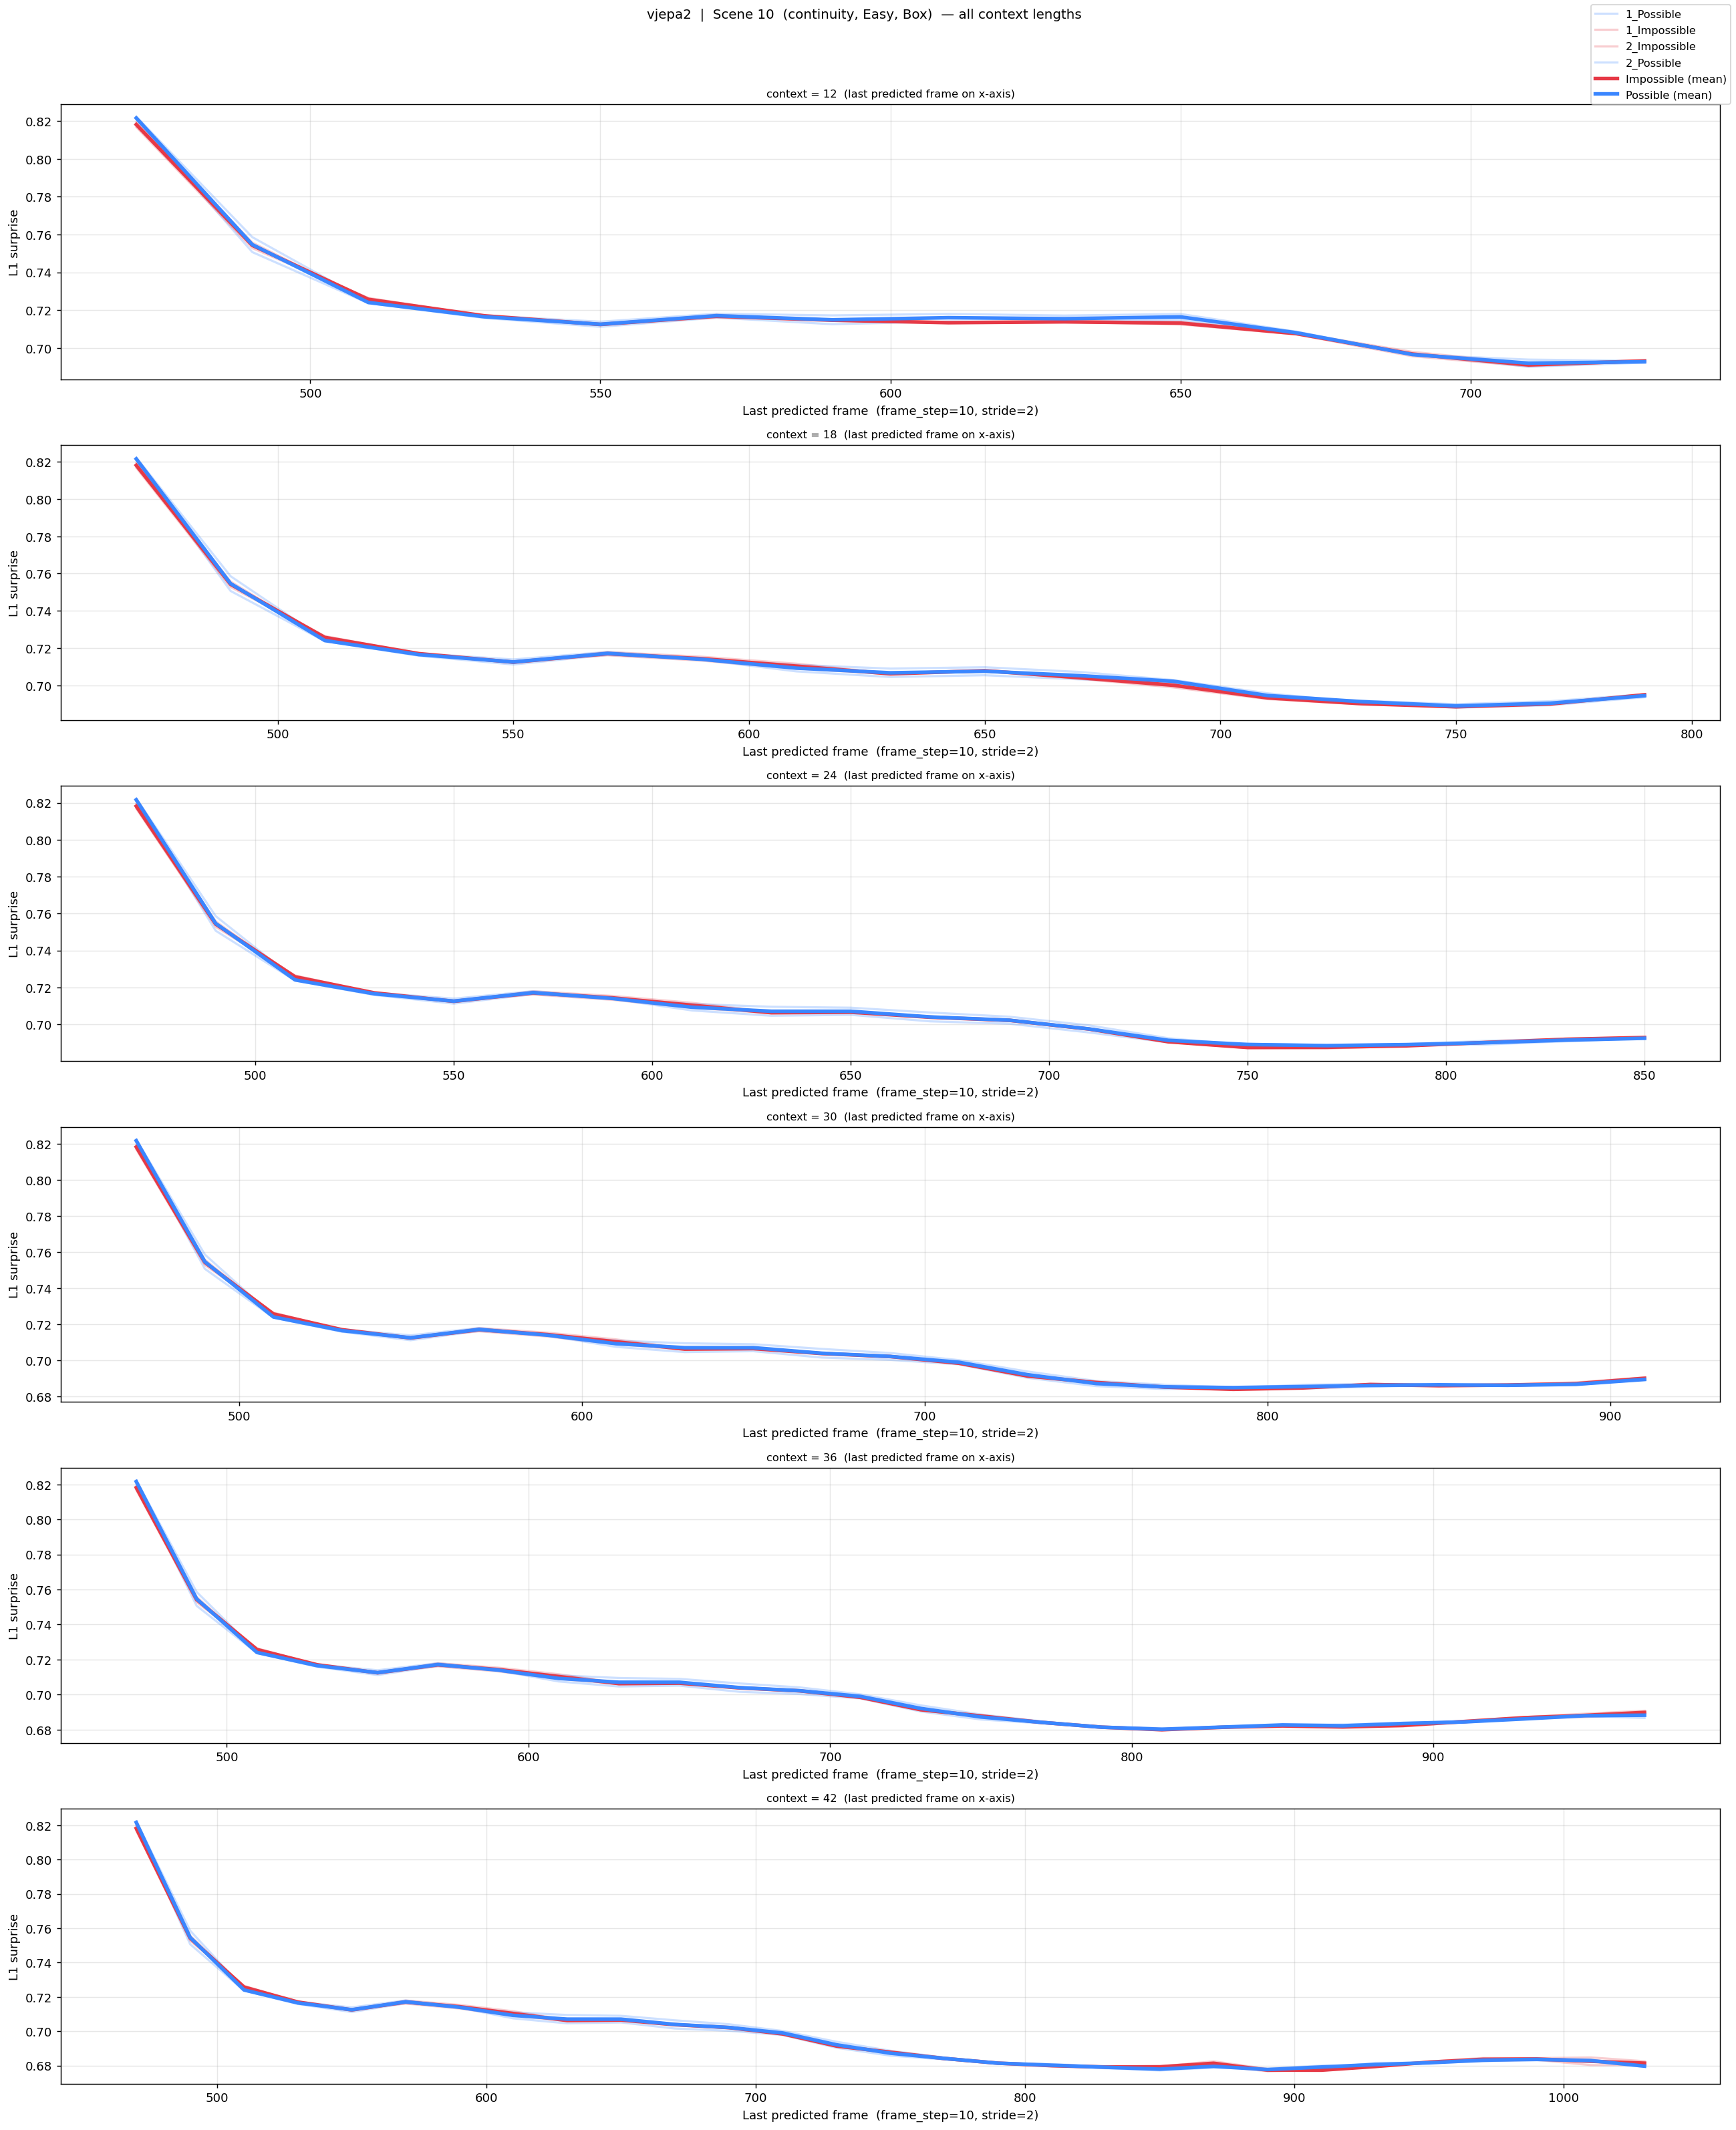

In [ ]:
# using last predicted frame 
def plot_surprise_all_ctx(scene_idx, frames_per_clip=FRAMES_PER_CLIP):
    frame_step = meta.get("frame_step", 1)
    palette    = {1: "#3a86ff", 0: "#e63946"}

    scene_df = results_df[results_df["SceneIndex"] == str(scene_idx)]
    if scene_df.empty:
        print(f"Scene {scene_idx} not found.")
        return
    scene_row = scene_df[["condition", "Difficulty", "game_name"]].iloc[0]

    n_ctx = len(ctx_lengths)
    fig, axes = plt.subplots(n_ctx, 1, figsize=(20, 4 * n_ctx), squeeze=False)

    for i, (c_len, ax) in enumerate(zip(ctx_lengths, axes.flatten())):
        traces_by_target = {0: [], 1: []}

        for _, row in scene_df.iterrows():
            vidx  = int(row["video_idx"])
            trace = losses[vidx, i, :].numpy()
            nz    = np.where(trace > 0)[0]
            if len(nz) == 0:
                continue
            trace  = trace[: nz[-1] + 1]
            frames = last_predicted_frame(
                np.arange(len(trace)), ctx_len=c_len,
                frames_per_clip=frames_per_clip, frame_step=frame_step,
            )
            color = palette.get(row["target"], "gray")
            ax.plot(frames, trace, color=color, linewidth=1.8, alpha=0.25,
                    label=row["type"] if i == 0 else "_")
            if row["target"] in traces_by_target:
                traces_by_target[row["target"]].append((frames, trace))

        for target, pairs in traces_by_target.items():
            if not pairs:
                continue
            max_len    = max(len(t) for _, t in pairs)
            padded_t   = np.array([np.pad(t, (0, max_len - len(t))) for _, t in pairs])
            padded_f   = np.array([np.pad(f, (0, max_len - len(f))) for f, _ in pairs])
            mask       = padded_t > 0
            avg        = np.where(mask.sum(0) > 0, (padded_t * mask).sum(0) / mask.sum(0).clip(1), np.nan)
            avg_frames = padded_f[0]  # frames are identical across videos for same ctx
            color      = palette[target]
            label      = f"{'Possible' if target == 1 else 'Impossible'} (mean)"
            ax.plot(avg_frames, avg, color=color, linewidth=3, alpha=1.0, label=label if i == 0 else "_")

        ax.set_title(f"context = {c_len}  (last predicted frame on x-axis)", fontsize=9)
        ax.set_xlabel(f"Last predicted frame  (frame_step={frame_step}, stride={STRIDE})")
        ax.set_ylabel("L1 surprise")
        ax.grid(alpha=0.3)

    handles, labels = axes.flatten()[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=9)
    fig.suptitle(
        f"{MODEL_NAME}  |  Scene {scene_idx}  "
        f"({scene_row['condition']}, {scene_row['Difficulty']}, {scene_row['game_name']})  — all context lengths",
        fontsize=11, y=1.02,
    )
    plt.tight_layout(rect=[0, 0, 1, 1.0])
    savefig(fig, f"surprise_scene{scene_idx}_all_ctx", 'figures/surprise_last_frame')
    plt.show()

Saved: figures/surprise_last_frame/vjepa2_surprise_scene155_all_ctx.png


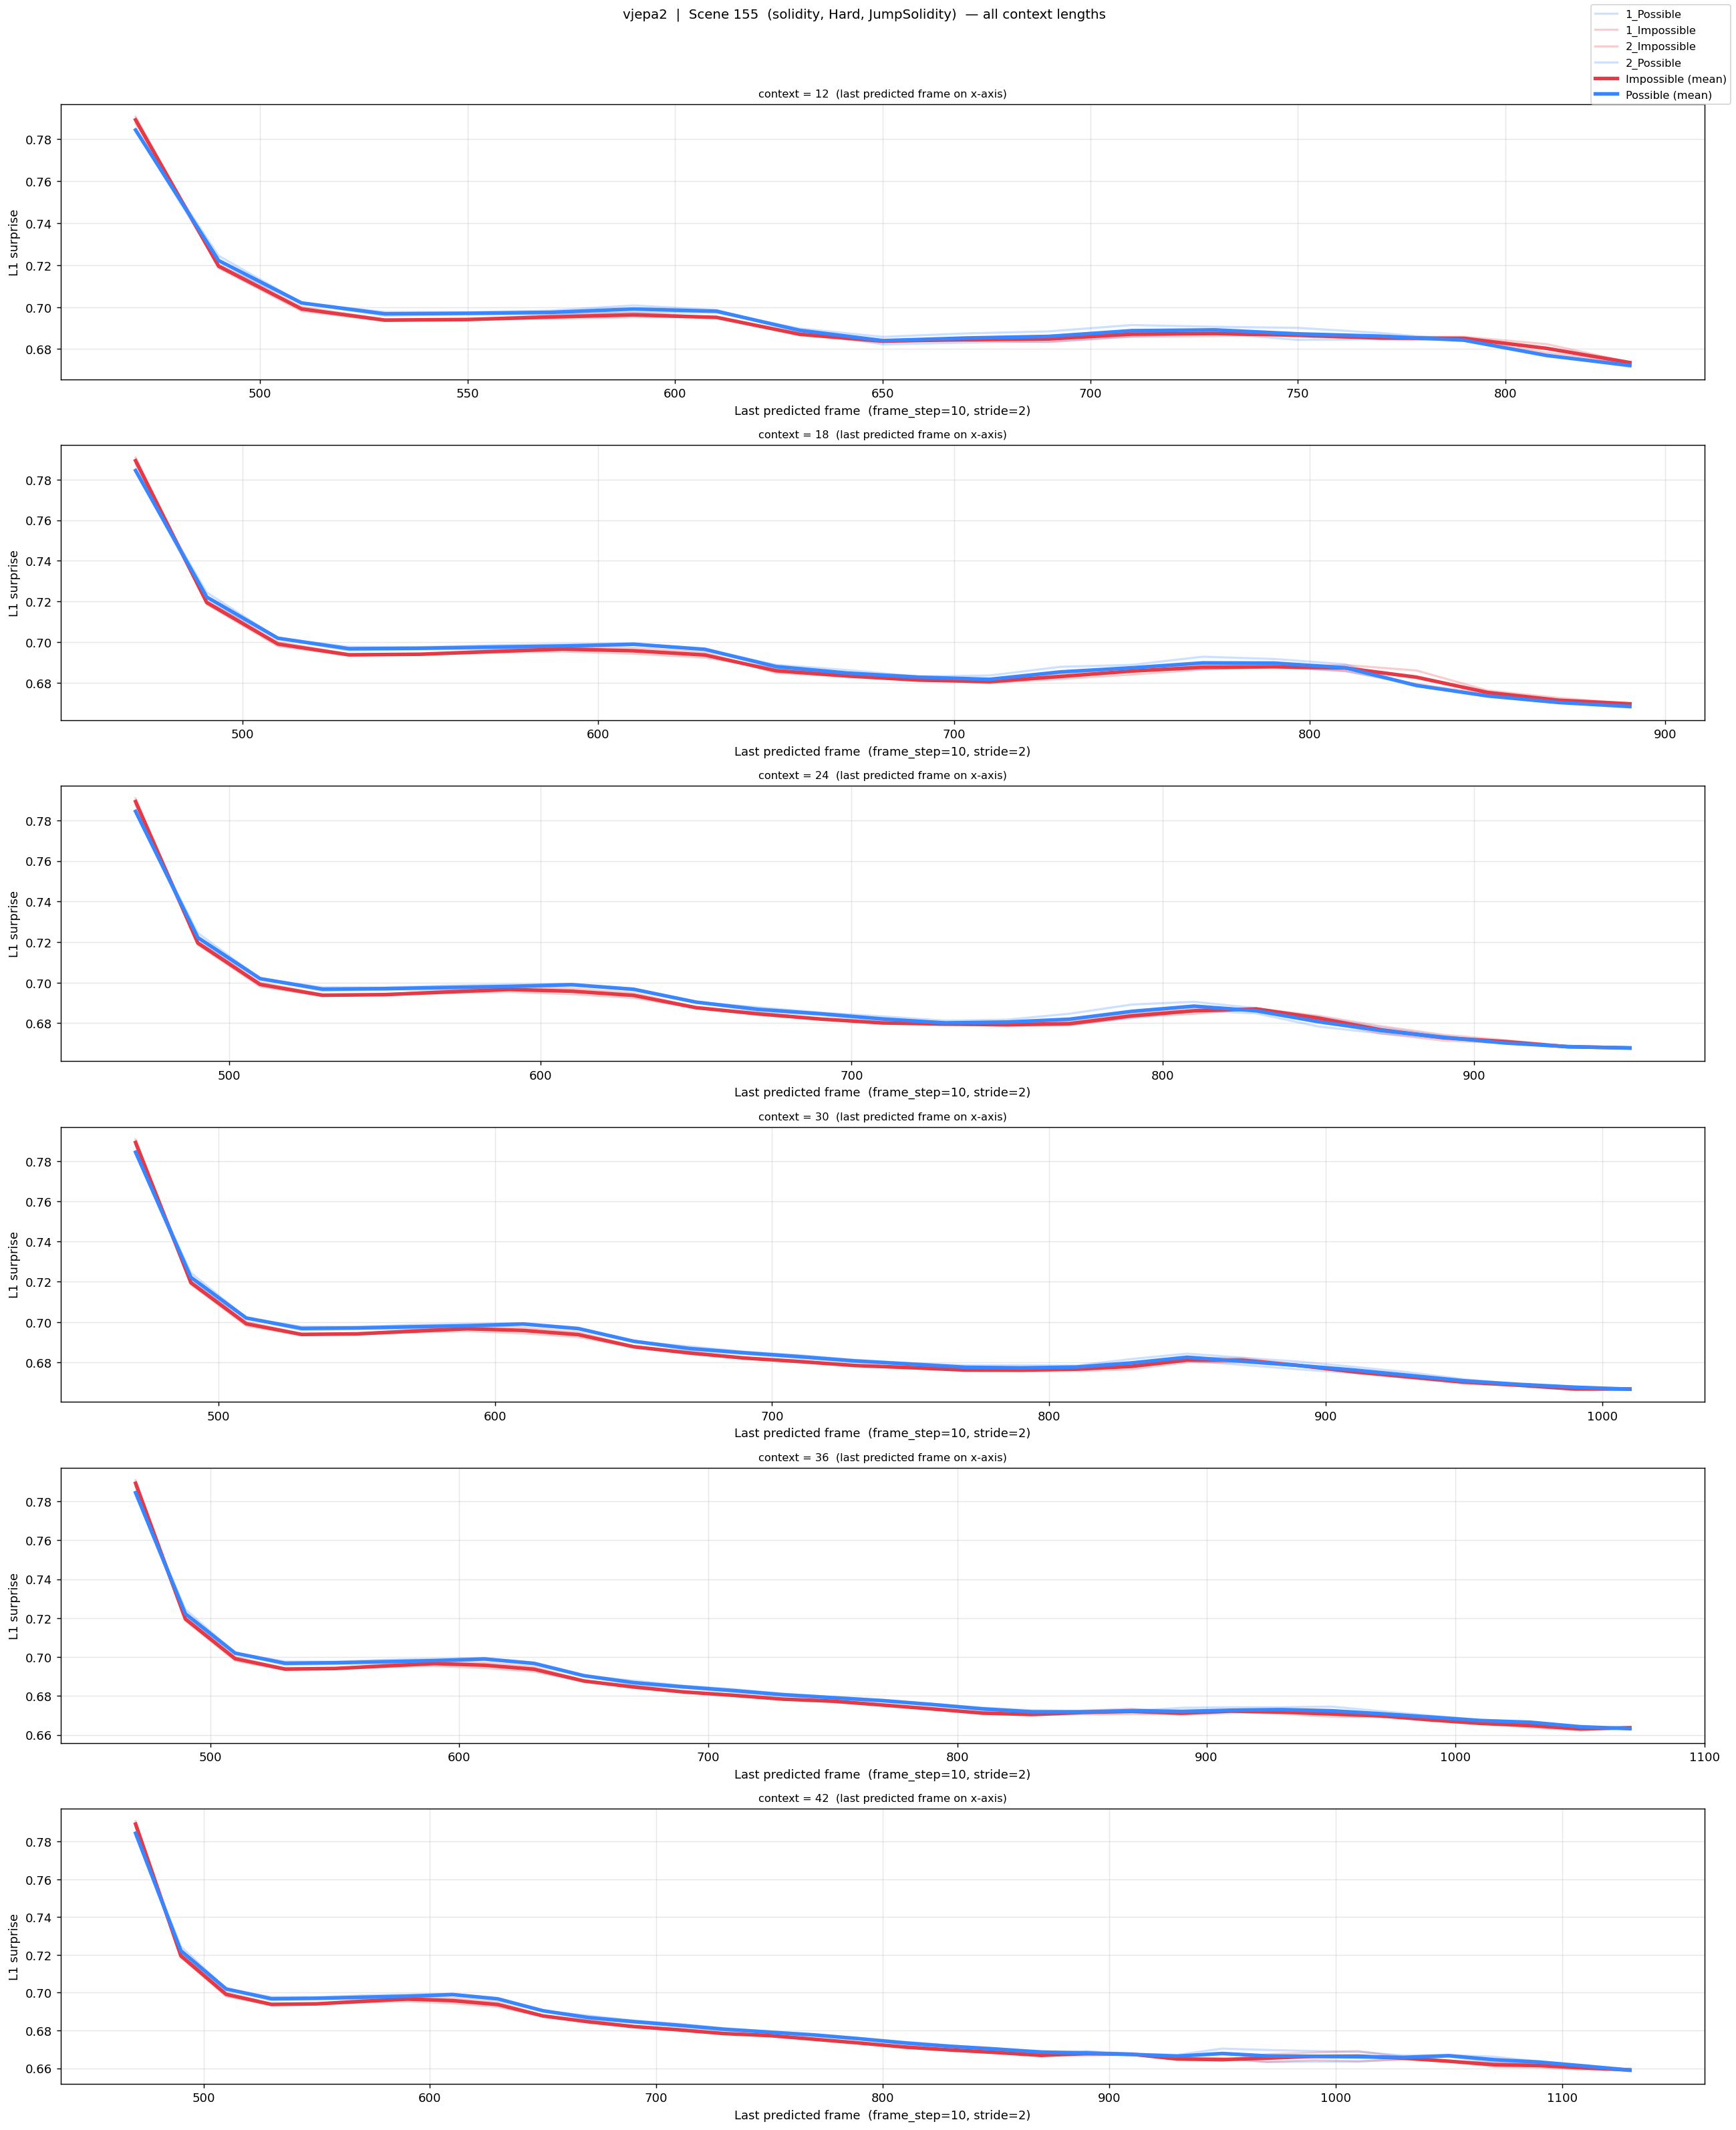

Saved: figures/surprise_last_frame/vjepa2_surprise_scene156_0_all_ctx.png


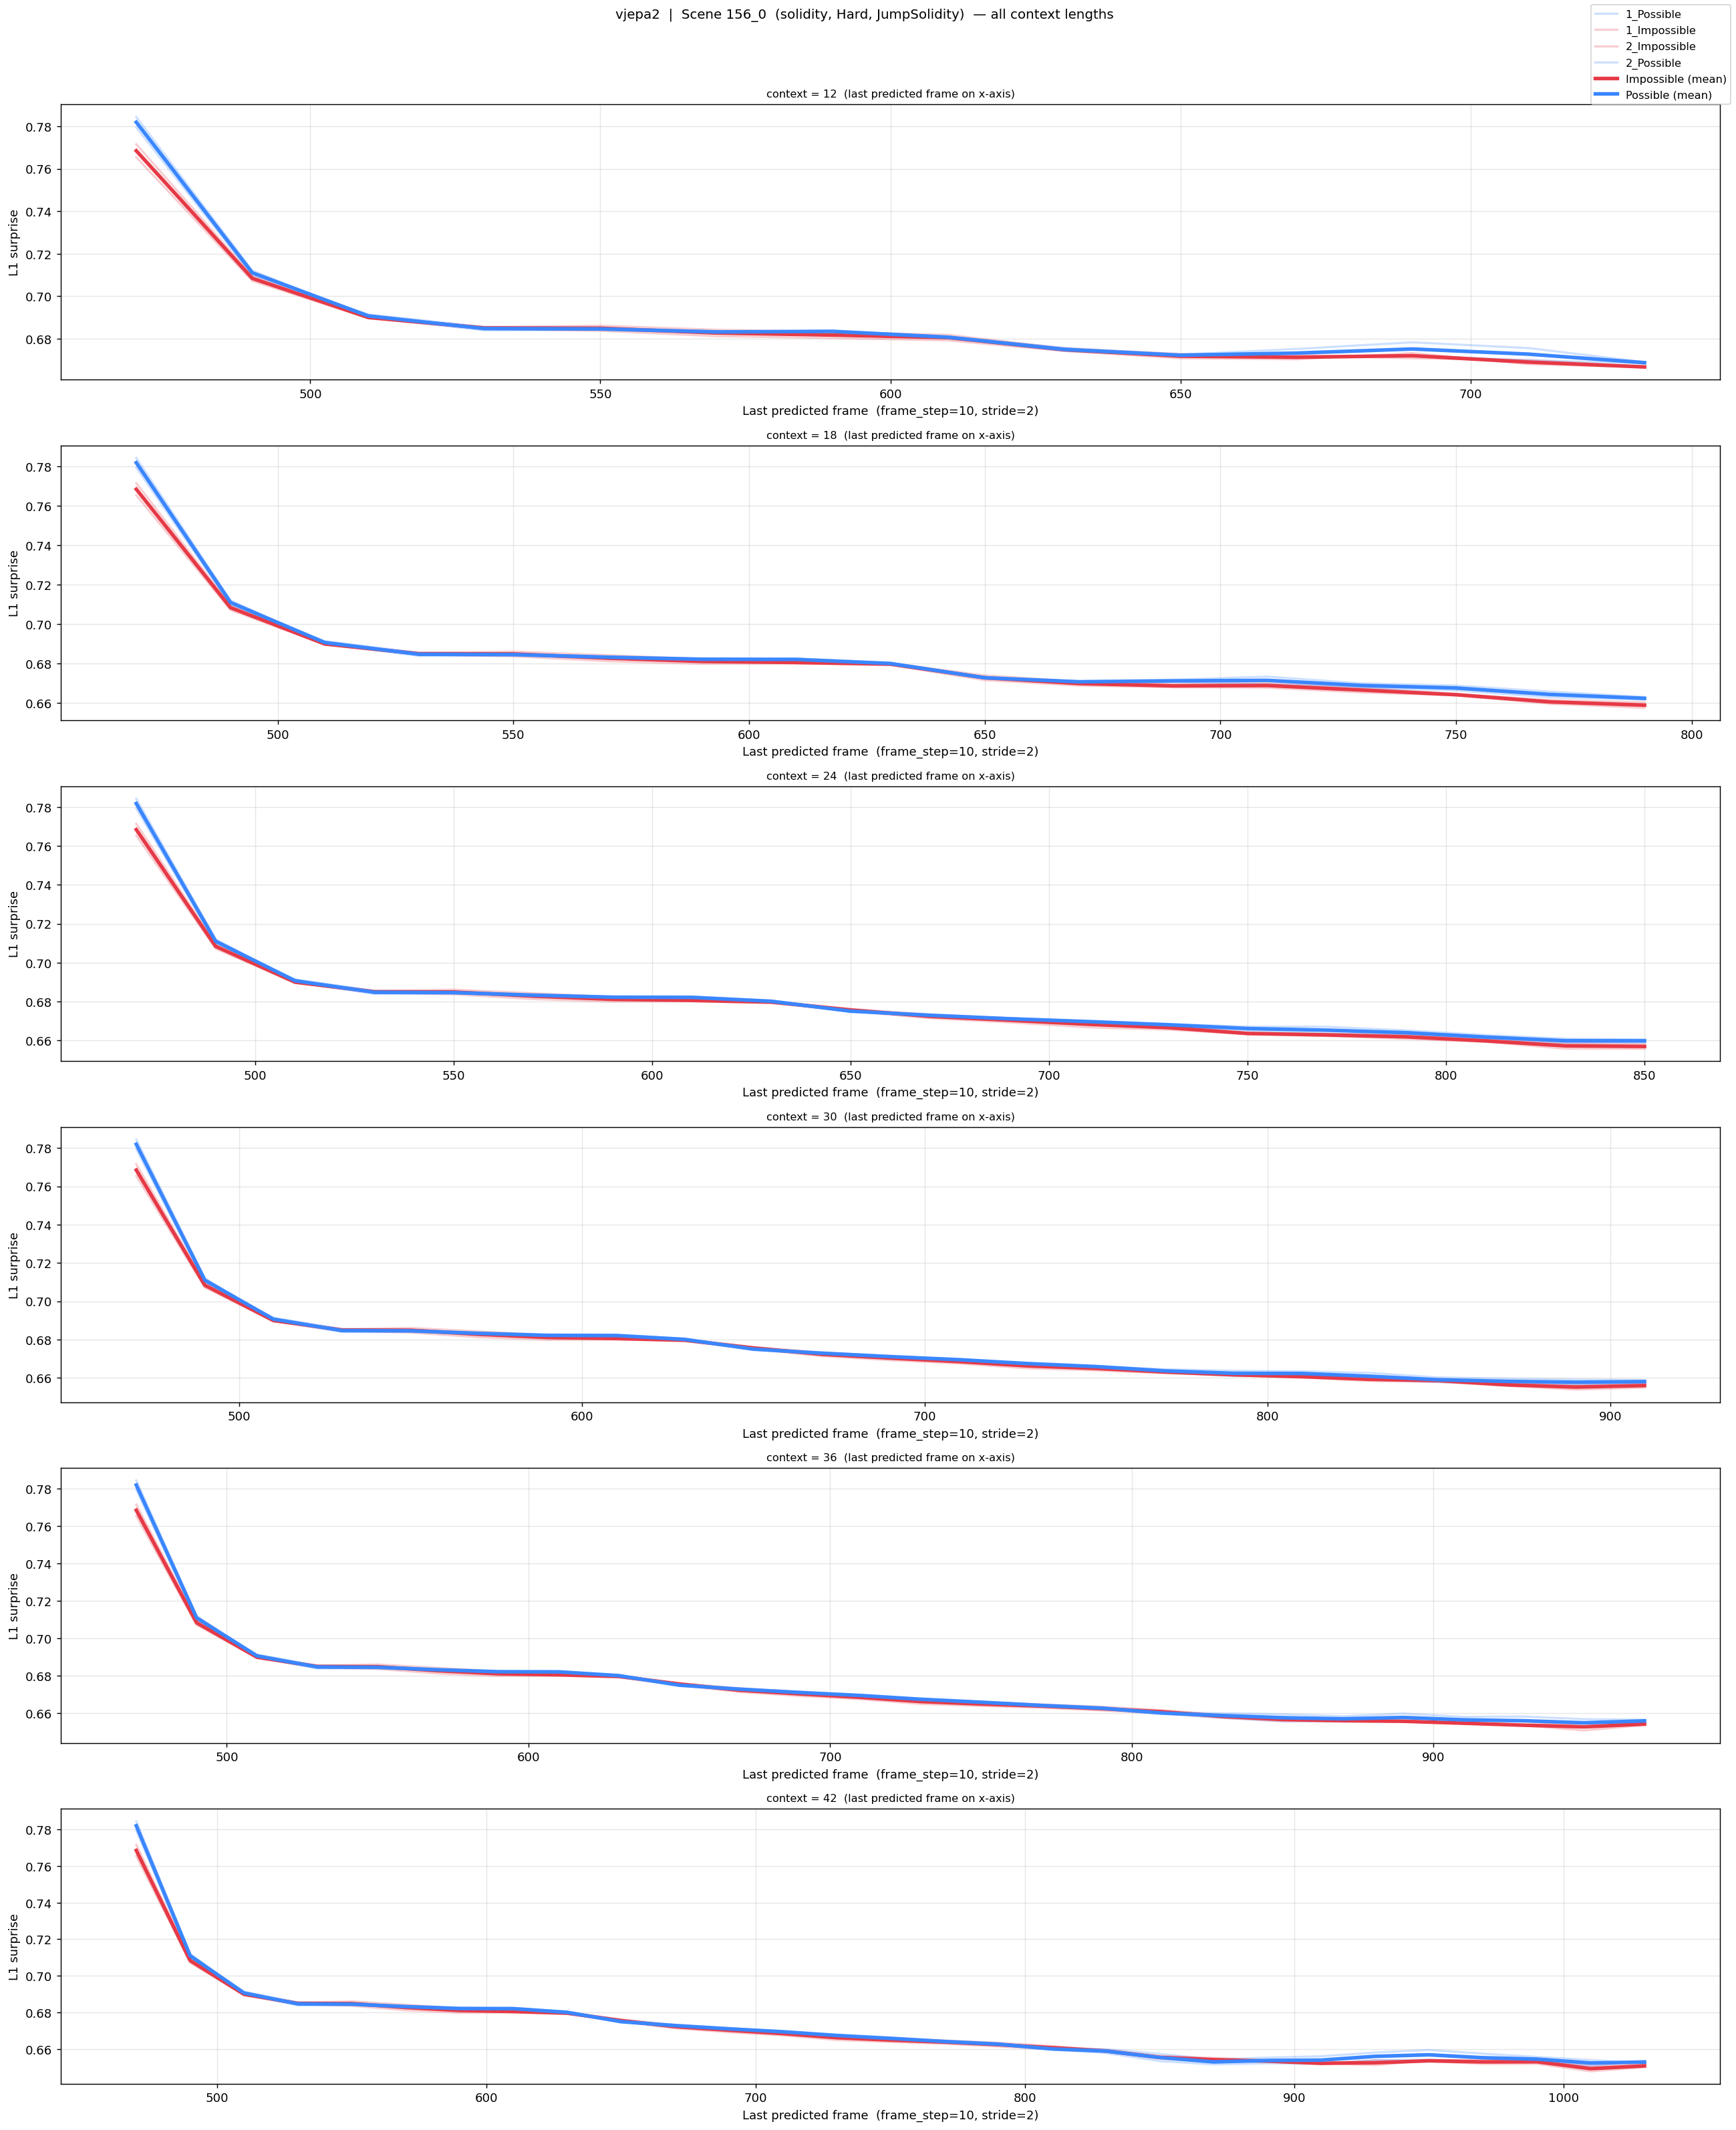

Saved: figures/surprise_last_frame/vjepa2_surprise_scene156_all_ctx.png


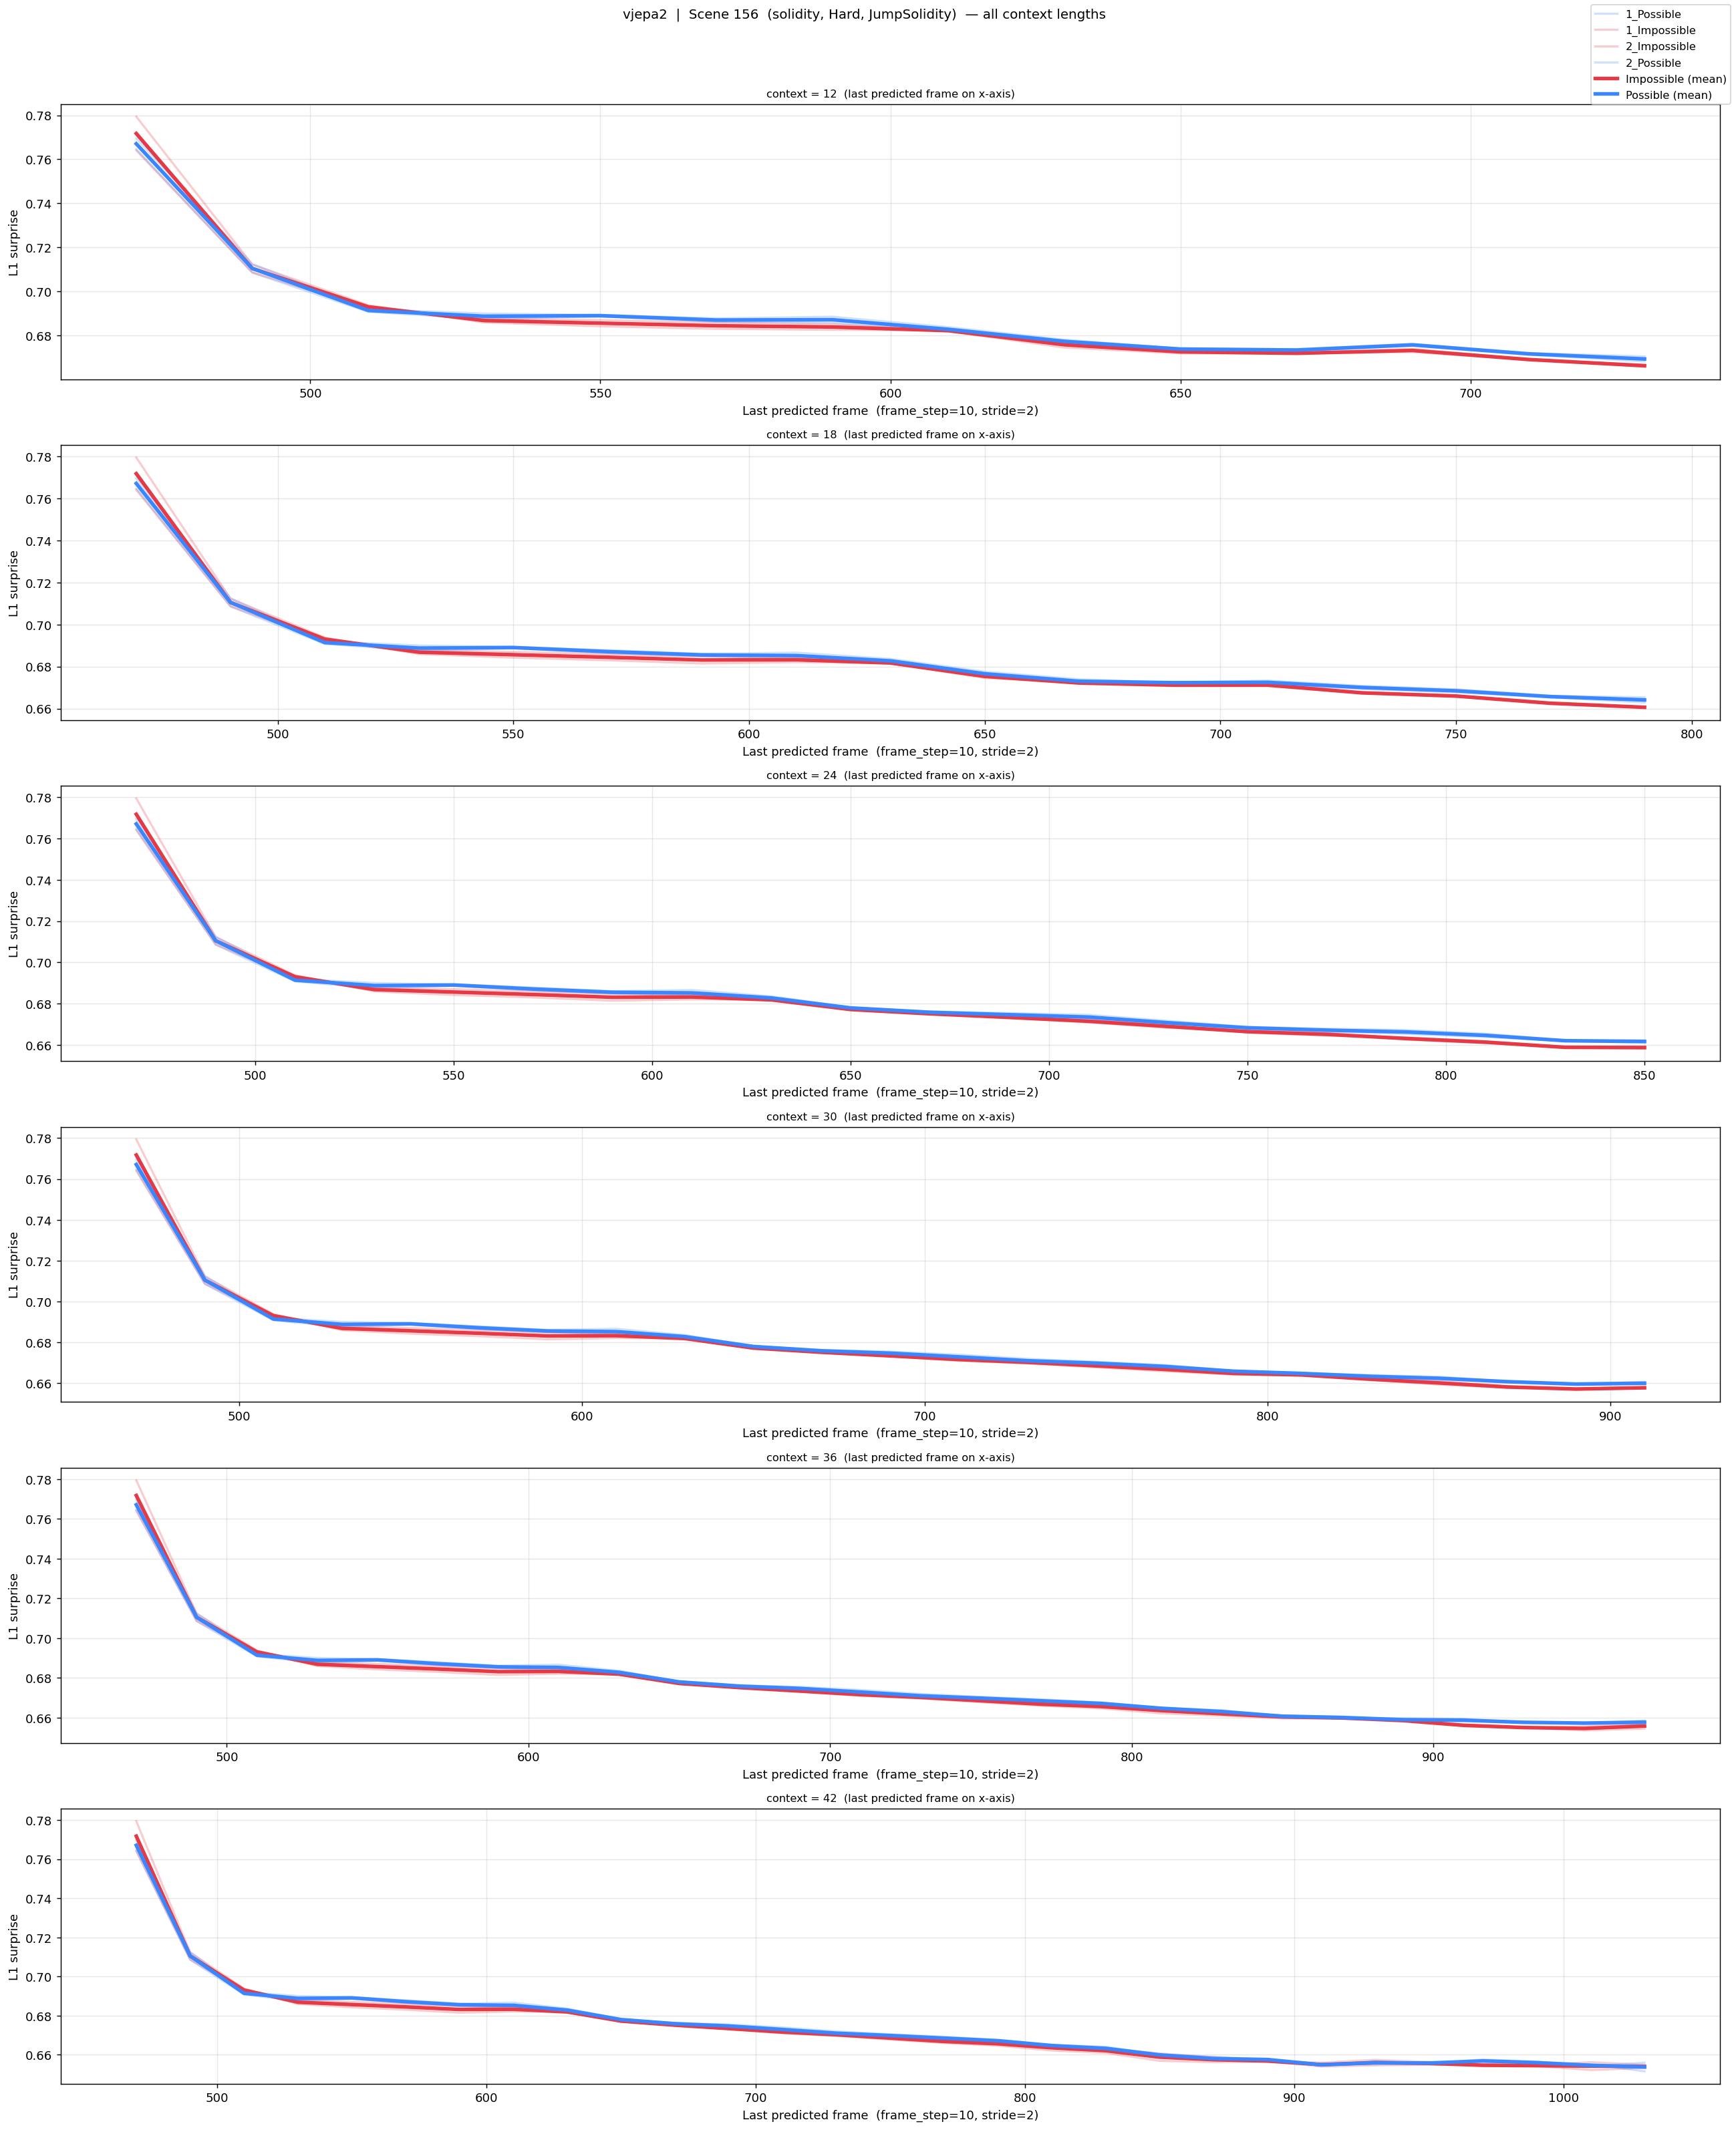

Saved: figures/surprise_last_frame/vjepa2_surprise_scene118_all_ctx.png


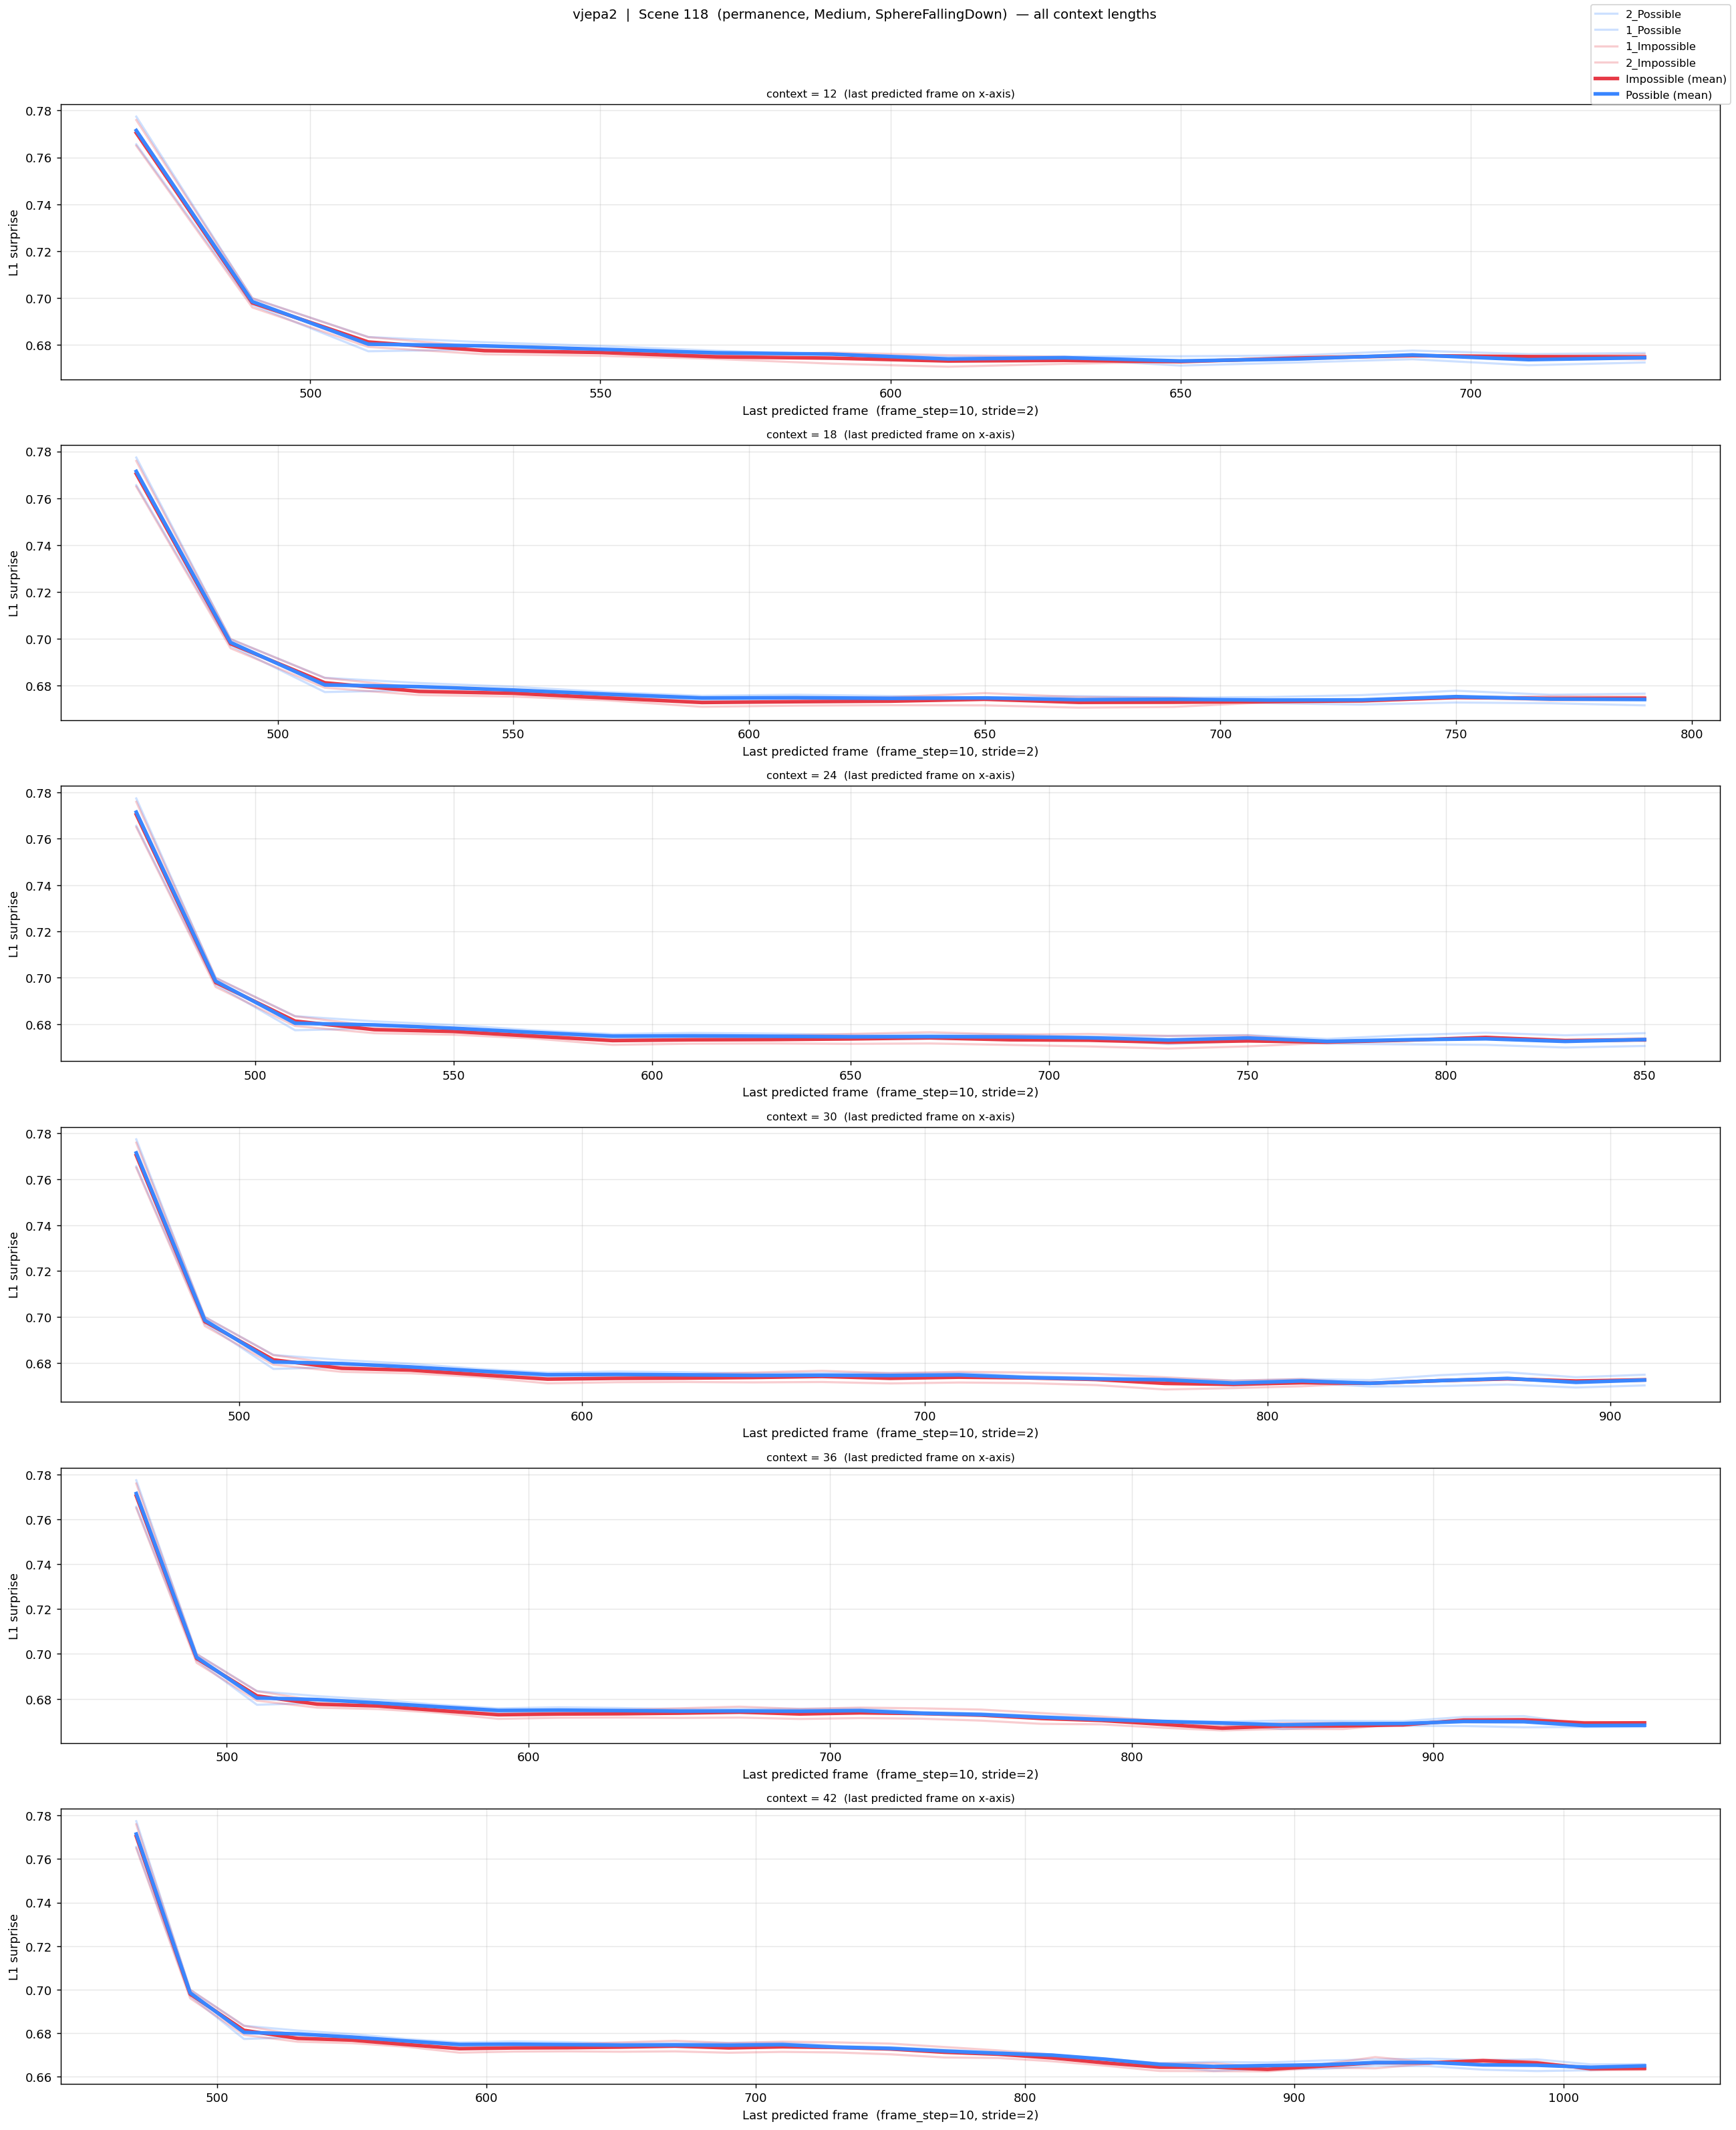

Saved: figures/surprise_last_frame/vjepa2_surprise_scene135_all_ctx.png


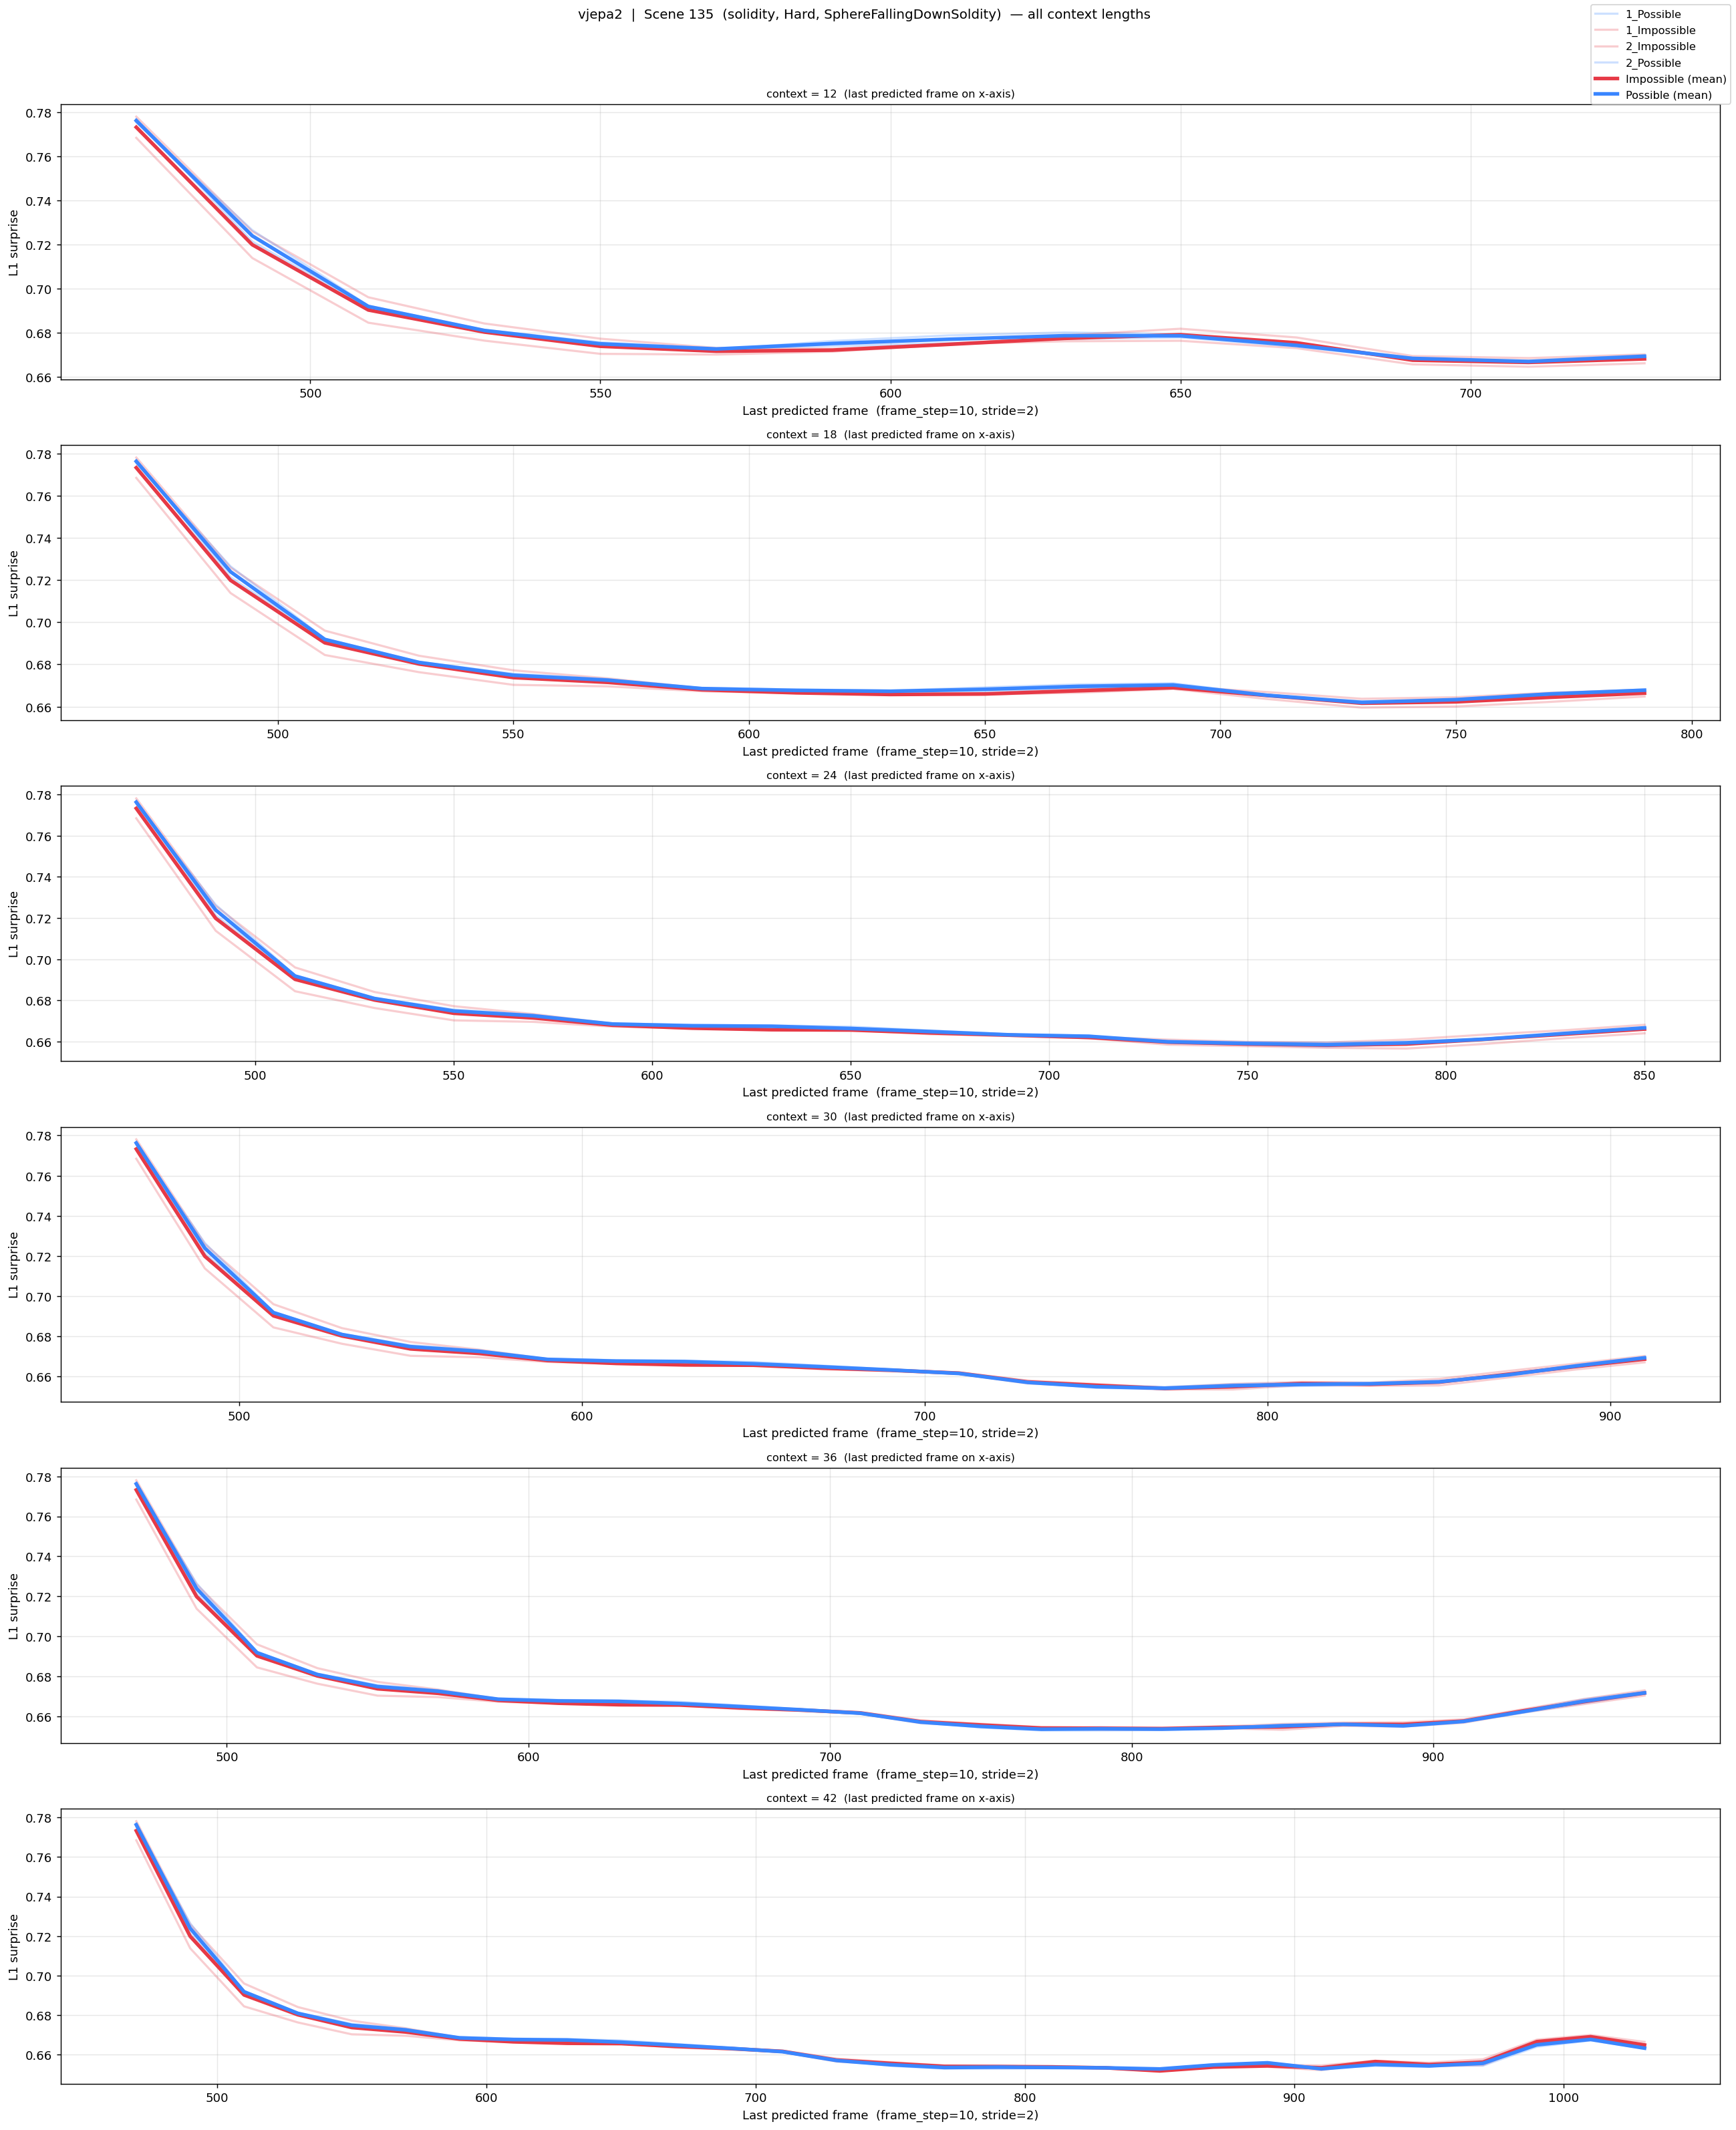

In [158]:
for s_i in list(incorrect_scenes['SceneIndex'])[:5]:
    plot_surprise_all_ctx(s_i)

In [ ]:
# fig, ax = plt.subplots(figsize=(20, 6))

# traces_by_target = {0: [], 1: []}

# for _, row in scene_df.iterrows():
#     vidx   = int(row["video_idx"])
#     trace  = losses[vidx, ctx_idx, :].numpy()
#     nz     = np.where(trace > 0)[0]
#     if len(nz) == 0:
#         continue
#     trace  = trace[: nz[-1] + 1]
#     frames = np.arange(len(trace)) * STRIDE * frame_step
#     color  = palette.get(row["target"], "gray")
#     label  = f"{row['type']} — {os.path.basename(str(row['file_name']))}"
#     ax.plot(frames, trace, color=color, linewidth=2, alpha=0.25, label=label)
#     if row["target"] in traces_by_target:
#         traces_by_target[row["target"]].append(trace)

# # Plot averages — pad traces to same length before averaging
# for target, traces in traces_by_target.items():
#     if not traces:
#         continue
#     max_len    = max(len(t) for t in traces)
#     padded     = np.array([np.pad(t, (0, max_len - len(t))) for t in traces])
#     mask       = padded > 0
#     avg        = np.where(mask.sum(0) > 0, (padded * mask).sum(0) / mask.sum(0).clip(1), np.nan)
#     avg_frames = np.arange(max_len) * STRIDE * frame_step
#     color      = palette[target]
#     label      = f"{'Possible' if target == 1 else 'Impossible'} (mean)"
#     ax.plot(avg_frames, avg, color=color, linewidth=3, alpha=1.0, label=label)

# ax.set_title(
#     f"{MODEL_NAME}  |  Scene {scene_idx}  "
#     f"({scene_row['condition']}, {scene_row['Difficulty']}, {scene_row['game_name']})  "
#     f"|  context = {ctx_len}"
# )
# ax.set_xlabel(f"Video frame  (sampled every {frame_step} frames, stride={STRIDE})")
# ax.set_ylabel("Surprise")
# ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
# ax.grid(alpha=0.3)
# plt.tight_layout()
# savefig(fig, f"surprise_scene{scene_idx}_ctx{ctx_len}")
# plt.show()

In [93]:
# ---------------------------------------------------------------------------
# Surprise over time — all context lengths for the selected scene
# ---------------------------------------------------------------------------

# n_ctx = len(ctx_lengths)
# ncols = min(n_ctx, 3)
# nrows = (n_ctx + ncols - 1) // ncols
# fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.5 * nrows), squeeze=False)

# for i, (c_len, ax) in enumerate(zip(ctx_lengths, axes.flatten())):
#     for _, row in scene_df.iterrows():
#         vidx  = int(row["video_idx"])
#         trace = losses[vidx, i, :].numpy()
#         nz    = np.where(trace > 0)[0]
#         if len(nz) == 0:
#             continue
#         trace  = trace[: nz[-1] + 1]
#         frames = np.arange(len(trace)) * STRIDE * frame_step
#         color  = palette.get(row["target"], "gray")
#         ax.plot(frames, trace, color=color, linewidth=1.8, alpha=0.9,
#                 label=row["type"] if i == 0 else "_")
#     ax.set_title(f"context = {c_len}", fontsize=9)
#     ax.set_xlabel("Video frame")
#     ax.set_ylabel("L1 surprise")
#     ax.grid(alpha=0.3)

# for ax in axes.flatten()[n_ctx:]:
#     ax.set_visible(False)

# handles, labels = axes.flatten()[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper right", fontsize=9)
# fig.suptitle(
#     f"{MODEL_NAME}  |  Scene {scene_idx}  "
#     f"({scene_row['condition']}, {scene_row['Difficulty']}, {scene_row['game_name']}) — all context lengths",
#     fontsize=11, y=1.01,
# )
# plt.tight_layout()
# savefig(fig, f"surprise_scene{scene_idx}_all_ctx")
# plt.show()